In [1]:
import pandas as pd

# Load the files
df1 = pd.read_csv("df_dropped_rows_w_statepartyna.csv")
df2 = pd.read_csv("df_dropped_rows.csv")

print(f"File 1 shape: {df1.shape}")
print(f"File 2 shape: {df2.shape}")
print(f"\nFile 1 columns: {df1.columns.tolist()}")
print(f"File 2 columns: {df2.columns.tolist()}")

File 1 shape: (26639, 9)
File 2 shape: (23317, 9)

File 1 columns: ['Chamber', 'Year', 'Speaker', 'Party', 'State', 'Title', 'speech_text', 'turn_number', 'speech_length_words']
File 2 columns: ['Chamber', 'Year', 'Speaker', 'Party', 'State', 'Title', 'speech_text', 'turn_number', 'speech_length_words']


In [3]:
# Assign to variables for clarity
df_with_state = pd.read_csv('df_dropped_rows_w_statepartyna.csv')
df_dropped = pd.read_csv('df_dropped_rows.csv')
print("With State/Party:")
print(f"Shape: {df_with_state.shape}")
print(f"Columns: {df_with_state.columns.tolist()}")
print(df_with_state.head(2))
print("\n" + "="*50 + "\n")

print("Dropped Rows:")
print(f"Shape: {df_dropped.shape}")
print(f"Columns: {df_dropped.columns.tolist()}")
print(df_dropped.head(2))

With State/Party:
Shape: (26639, 9)
Columns: ['Chamber', 'Year', 'Speaker', 'Party', 'State', 'Title', 'speech_text', 'turn_number', 'speech_length_words']
  Chamber  Year Speaker       Party State  \
0   House  2025    Hill  Republican    AR   
1   House  2025    Hill  Republican    AR   

                                               Title  \
0  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...   
1  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...   

                                         speech_text  turn_number  \
0  Mr. Speaker, I move to suspend the rules and p...            1   
1  Mr. Speaker, I ask unanimous consent that all ...            2   

   speech_length_words  
0                  422  
1                   48  


Dropped Rows:
Shape: (23317, 9)
Columns: ['Chamber', 'Year', 'Speaker', 'Party', 'State', 'Title', 'speech_text', 'turn_number', 'speech_length_words']
  Chamber  Year Speaker       Party State  \
0   House  2025    Hill  Republican    AR   
1   House  2

In [4]:
print("Before:")
print(f"df_with_state: {df_with_state.shape[0]} rows")
print(f"df_dropped: {df_dropped.shape[0]} rows")

# Drop duplicates
df_with_state = df_with_state.drop_duplicates()
df_dropped = df_dropped.drop_duplicates()

# After
print("\nAfter:")
print(f"df_with_state: {df_with_state.shape[0]} rows")
print(f"df_dropped: {df_dropped.shape[0]} rows")

# Save
df_with_state.to_csv('df_with_state_CLEANED.csv', index=False)
df_dropped.to_csv('df_dropped_CLEANED.csv', index=False)

Before:
df_with_state: 26639 rows
df_dropped: 23317 rows

After:
df_with_state: 26633 rows
df_dropped: 23311 rows


In [5]:
combined = pd.concat([df_with_state, df_dropped], ignore_index=True)

# Show result
print(f"df_with_state: {df_with_state.shape[0]} rows")
print(f"df_dropped: {df_dropped.shape[0]} rows")
print(f"Combined: {combined.shape[0]} rows")

# Save
combined.to_csv('COMBINED_DATA.csv', index=False)
print("\n✓ Saved: COMBINED_DATA.csv")

df_with_state: 26633 rows
df_dropped: 23311 rows
Combined: 49944 rows

✓ Saved: COMBINED_DATA.csv


In [6]:
print("="*80)
print("BEFORE")
print("="*80)
print(f"df_with_state: {df_with_state.shape[0]} rows")
print(f"df_dropped: {df_dropped.shape[0]} rows")

# COMBINE
combined = pd.concat([df_with_state, df_dropped])


BEFORE
df_with_state: 26633 rows
df_dropped: 23311 rows


In [7]:
combined = pd.read_csv('COMBINED_DATA.csv')  # or whatever you named it

# Show all column names
print("Columns in your data:")
print(combined.columns.tolist())

# Show first few rows
print("\nFirst 5 rows:")
print(combined.head())

# Show unique values in each column
print("\n\nUnique values in each column:")
for col in combined.columns:
    unique_vals = combined[col].unique()
    if len(unique_vals) < 20:
        print(f"\n{col}:")
        print(list(unique_vals))

Columns in your data:
['Chamber', 'Year', 'Speaker', 'Party', 'State', 'Title', 'speech_text', 'turn_number', 'speech_length_words']

First 5 rows:
  Chamber  Year Speaker       Party State  \
0   House  2025    Hill  Republican    AR   
1   House  2025    Hill  Republican    AR   
2   House  2025    Hill  Republican    AR   
3   House  2025  Vargas    Democrat    CA   
4   House  2025    Hill  Republican    AR   

                                               Title  \
0  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...   
1  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...   
2  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...   
3  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...   
4  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...   

                                         speech_text  turn_number  \
0  Mr. Speaker, I move to suspend the rules and p...            1   
1  Mr. Speaker, I ask unanimous consent that all ...            2   
2  Mr. Speaker, I yield myself such t

In [8]:

# Load combined data
combined = pd.read_csv('COMBINED_DATA.csv')

print("="*80)
print("BEFORE FILTERING")
print("="*80)
print(f"Total rows: {combined.shape[0]}")


# FILTER: ACTS (Title contains "ACT")


acts = combined[combined['Title'].str.contains('ACT', case=False, na=False)]

print(f"\nActs (Title contains 'ACT'): {acts.shape[0]} rows")
print("\nFirst act:")
print(acts[['Title', 'Speaker', 'speech_text']].head(1))


# FILTER: SPEECHES (Title does NOT contain "ACT")


speeches = combined[~combined['Title'].str.contains('ACT', case=False, na=False)]

print(f"\n\nSpeeches (Title does NOT contain 'ACT'): {speeches.shape[0]} rows")
print("\nFirst speech:")
print(speeches[['Title', 'Speaker', 'speech_text']].head(1))


# SAVE BOTH


acts.to_csv('ACTS_ONLY.csv', index=False)
speeches.to_csv('SPEECHES_ONLY.csv', index=False)

print("\n" + "="*80)
print("✓ SAVED:")
print("="*80)
print(f"  - ACTS_ONLY.csv ({acts.shape[0]} rows)")
print(f"  - SPEECHES_ONLY.csv ({speeches.shape[0]} rows)")

BEFORE FILTERING
Total rows: 49944

Acts (Title contains 'ACT'): 49944 rows

First act:
                                               Title Speaker  \
0  HOUSING UNHOUSED DISABLED VETERANS ACT; Congre...    Hill   

                                         speech_text  
0  Mr. Speaker, I move to suspend the rules and p...  


Speeches (Title does NOT contain 'ACT'): 0 rows

First speech:
Empty DataFrame
Columns: [Title, Speaker, speech_text]
Index: []

✓ SAVED:
  - ACTS_ONLY.csv (49944 rows)
  - SPEECHES_ONLY.csv (0 rows)


In [9]:
# Get unique acts
acts_list = combined['Title'].unique()
print(f"Total unique acts: {len(acts_list)}")

# Save each act separately
for act in acts_list[:5]:  # First 5 acts as example
    act_speeches = combined[combined['Title'] == act]
    filename = f"ACT_{act[:30]}.csv"
    act_speeches.to_csv(filename, index=False)
    print(f"Saved: {filename} ({act_speeches.shape[0]} speeches)")

Total unique acts: 1433
Saved: ACT_HOUSING UNHOUSED DISABLED VETE.csv (18 speeches)
Saved: ACT_HOMELESS ASSISTANCE ACT OF 201.csv (11 speeches)
Saved: ACT_HOMELESS VETERAN FAMILIES ACT;.csv (26 speeches)
Saved: ACT_HOMELESS VETERANS ASSISTANCE A.csv (7 speeches)
Saved: ACT_HOMELESS VETERANS WITH CHILDRE.csv (18 speeches)


In [10]:
combined = pd.read_csv('COMBINED_DATA.csv')

# ============================================================================
# GET ALL UNIQUE ACTS
# ============================================================================

unique_acts = combined['Title'].unique()
print(f"Total unique acts: {len(unique_acts)}")

# ============================================================================
# FILTER FOR HOMELESSNESS-RELATED ACTS
# ============================================================================

homelessness_keywords = ['HOMELESS', 'HOUSING', 'UNHOUSED', 'VETERANS', 'MENTAL HEALTH', 'DISABILITY']

homelessness_acts = combined[
    combined['Title'].str.contains('|'.join(homelessness_keywords), case=False, na=False)
]

print(f"\nHomelessness-related acts: {homelessness_acts.shape[0]} rows")
print(f"Unique homelessness acts: {homelessness_acts['Title'].nunique()}")

# Show which acts
print("\nHomelessness acts:")
for act in homelessness_acts['Title'].unique():
    count = len(homelessness_acts[homelessness_acts['Title'] == act])
    print(f"  - {act[:70]} ({count} speeches)")

# Save
homelessness_acts.to_csv('HOMELESSNESS_ACTS_ONLY.csv', index=False)
print(f"\n✓ Saved: HOMELESSNESS_ACTS_ONLY.csv ({homelessness_acts.shape[0]} rows)")

# ============================================================================
# SUMMARY BY ACT
# ============================================================================

print("\n" + "="*80)
print("SUMMARY BY ACT")
print("="*80)

act_summary = combined.groupby('Title').agg({
    'Speaker': 'count',
    'Year': 'first',
    'Chamber': 'first',
    'speech_length_words': 'sum'
}).rename(columns={'Speaker': 'speech_count', 'speech_length_words': 'total_words'})

act_summary = act_summary.sort_values('speech_count', ascending=False)

print("\nTop 10 acts by number of speeches:")
print(act_summary.head(10))

# Save summary
act_summary.to_csv('ACT_SUMMARY.csv')
print(f"\n✓ Saved: ACT_SUMMARY.csv")

Total unique acts: 1433

Homelessness-related acts: 10781 rows
Unique homelessness acts: 334

Homelessness acts:
  - HOUSING UNHOUSED DISABLED VETERANS ACT; Congressional Record Vol. 171, (18 speeches)
  - HOMELESS ASSISTANCE ACT OF 2019; Congressional Record Vol. 166, No. 7 (11 speeches)
  - HOMELESS VETERAN FAMILIES ACT; Congressional Record Vol. 165, No. 162 (26 speeches)
  - HOMELESS VETERANS ASSISTANCE ACT OF 2004; Congressional Record Vol. 15 (7 speeches)
  - HOMELESS VETERANS WITH CHILDREN REINTEGRATION ACT; Congressional Recor (18 speeches)
  - RECONNECTING HOMELESS YOUTH ACT OF 2008; Congressional Record Vol. 154 (16 speeches)
  - RUNAWAY AND HOMELESS PROTECTION ACT; Congressional Record Vol. 154, No (4 speeches)
  - TRIBAL ACCESS TO HOMELESS ASSISTANCE ACT; Congressional Record Vol. 16 (12 speeches)
  - HOMELESS EMERGENCY ASSISTANCE AND RAPID TRANSITION TO HOUSING ACT OF 2 (32 speeches)
  - RECOGNIZING THE 20TH ANNIVERSARY OF THE McKINNEY-VENTO HOMELESS ASSIST (18 speeches)
 

In [26]:
from sklearn.model_selection import train_test_split
from textblob import TextBlob

# Load data
homelessness = pd.read_csv('HOMELESSNESS_ACTS_ONLY.csv')

# Split 80/20
train, test = train_test_split(homelessness, test_size=0.2, random_state=42)

print(f"Training: {len(train)} speeches (80%)")
print(f"Test: {len(test)} speeches (20%)")

# Sentiment function
def get_sentiment(text):
    if pd.isna(text):
        return None, None
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        label = 'positive'
    elif polarity < -0.1:
        label = 'negative'
    else:
        label = 'neutral'
    return polarity, label

# Analyze training set

print("TRAINING SET (80%)")

train[['polarity', 'sentiment']] = train['speech_text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(f"\nAverage sentiment: {train['polarity'].mean():.3f}")
print(f"\nSentiment breakdown:")
print(train['sentiment'].value_counts())
print(f"\nBy Party:")
print(train.groupby('Party')['polarity'].mean())

# Analyze test set

print("TEST SET (20%)")

test[['polarity', 'sentiment']] = test['speech_text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(f"\nAverage sentiment: {test['polarity'].mean():.3f}")
print(f"\nSentiment breakdown:")
print(test['sentiment'].value_counts())
print(f"\nBy Party:")
print(test.groupby('Party')['polarity'].mean())

# Validation

print("VALIDATION: TRAINING vs TEST")

print(f"\nTrain avg polarity: {train['polarity'].mean():.4f}")
print(f"Test avg polarity: {test['polarity'].mean():.4f}")
print(f"Difference: {abs(train['polarity'].mean() - test['polarity'].mean()):.4f}")

# Save
train.to_csv('TRAIN_SENTIMENT.csv', index=False)
test.to_csv('TEST_SENTIMENT.csv', index=False)

print("\n✓ Saved: TRAIN_SENTIMENT.csv and TEST_SENTIMENT.csv")

Training: 8624 speeches (80%)
Test: 2157 speeches (20%)
TRAINING SET (80%)

Average sentiment: 0.102

Sentiment breakdown:
sentiment
neutral     4335
positive    4034
negative     255
Name: count, dtype: int64

By Party:
Party
Democrat       0.105506
Independent    0.088796
Republican     0.100466
Name: polarity, dtype: float64
TEST SET (20%)

Average sentiment: 0.104

Sentiment breakdown:
sentiment
neutral     1087
positive    1005
negative      65
Name: count, dtype: int64

By Party:
Party
Democrat       0.106985
Independent    0.105629
Republican     0.103770
Name: polarity, dtype: float64
VALIDATION: TRAINING vs TEST

Train avg polarity: 0.1023
Test avg polarity: 0.1037
Difference: 0.0014

✓ Saved: TRAIN_SENTIMENT.csv and TEST_SENTIMENT.csv


Before removing Independents:
  Train: 8624
  Test: 2157

After removing Independents:
  Train: 7967
  Test: 1985
✓ Saved: 01_train_sentiment_distribution.png


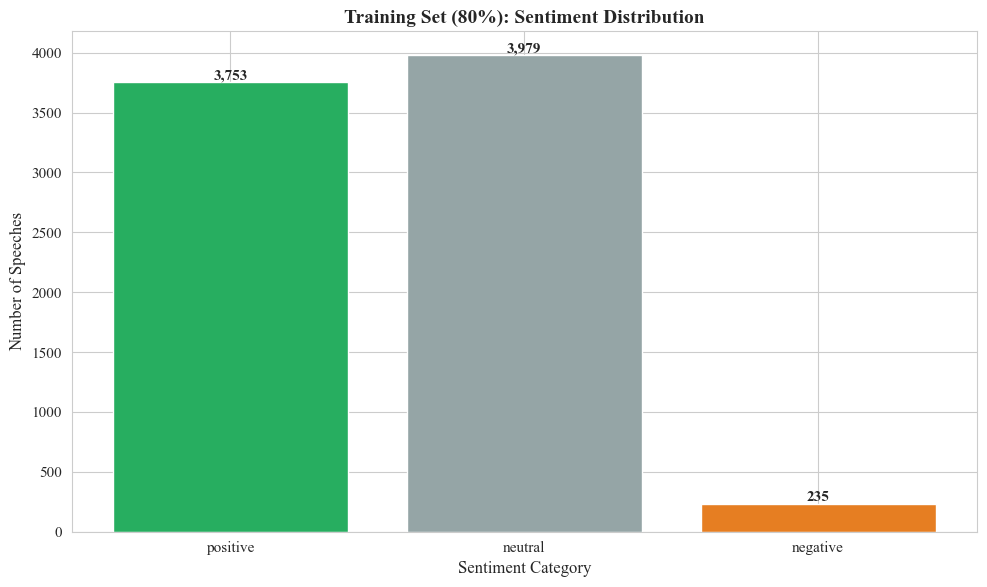

✓ Saved: 02_test_sentiment_distribution.png


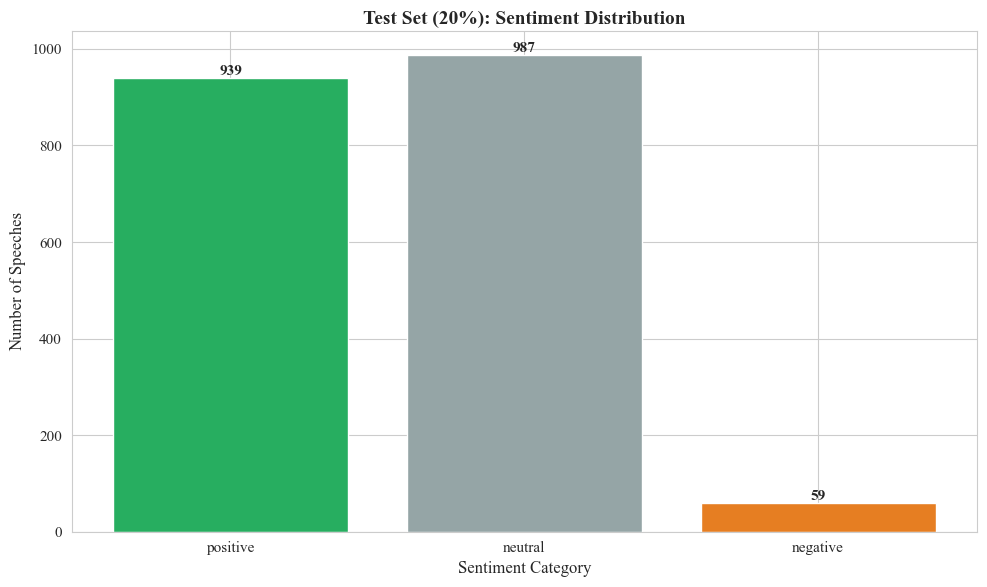

✓ Saved: 03_train_sentiment_pie.png


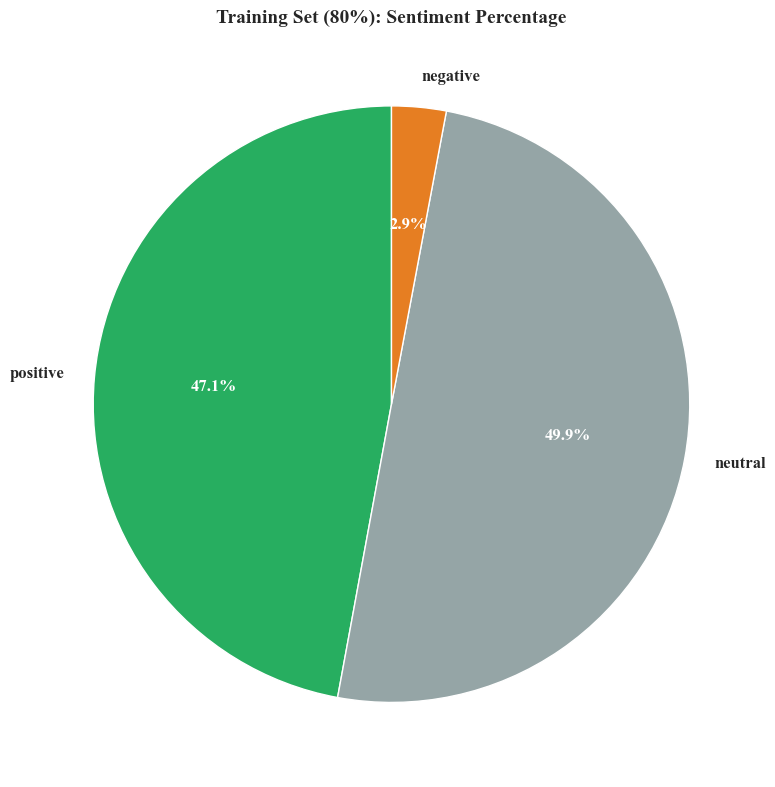

✓ Saved: 04_test_sentiment_pie.png


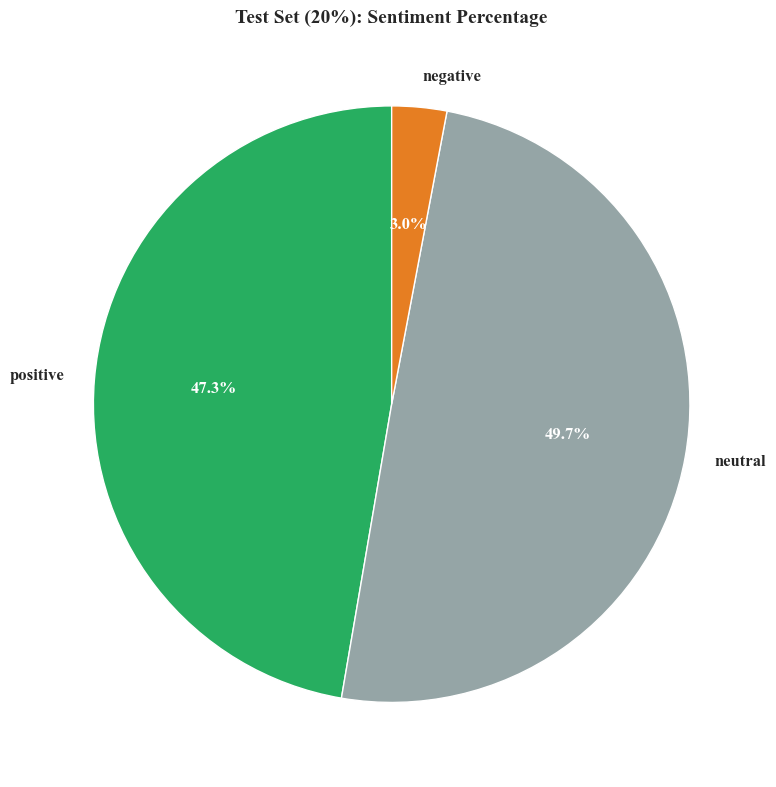

✓ Saved: 05_polarity_histogram.png


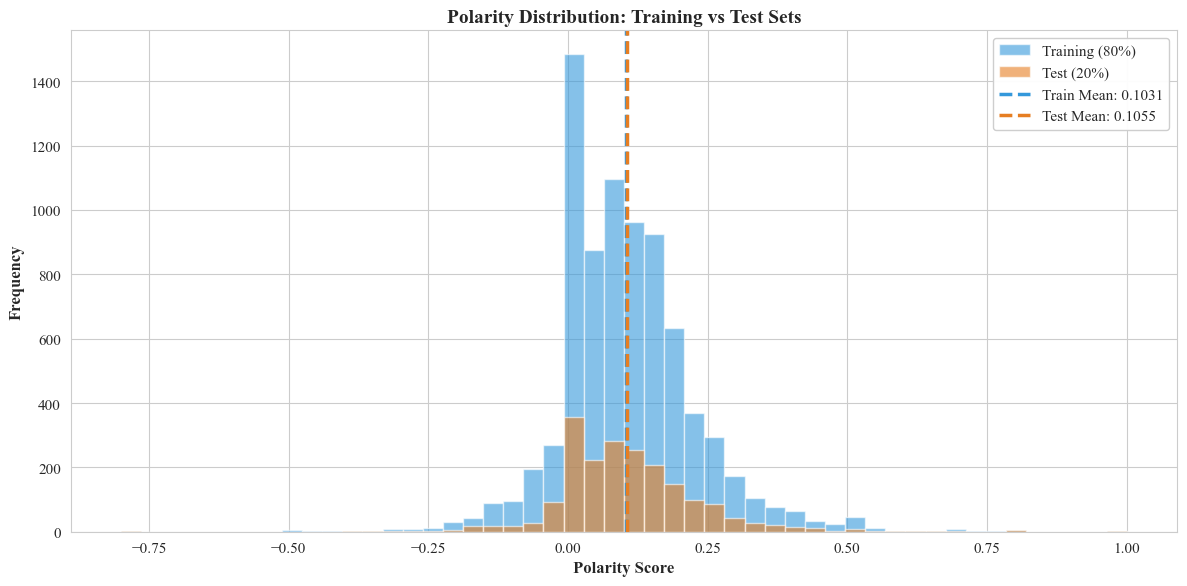

✓ Saved: 06_polarity_boxplot.png


/var/folders/vx/xc7347n175s50g85_65zycxc0000gn/T/ipykernel_13169/763104125.py:171: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([train['polarity'], test['polarity']],


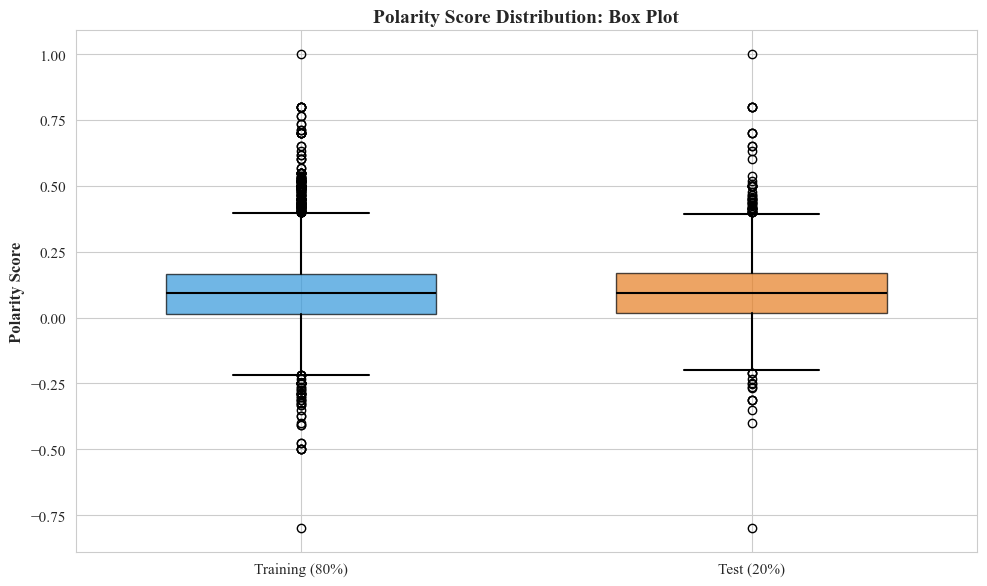

✓ Saved: 07_train_sentiment_by_party.png


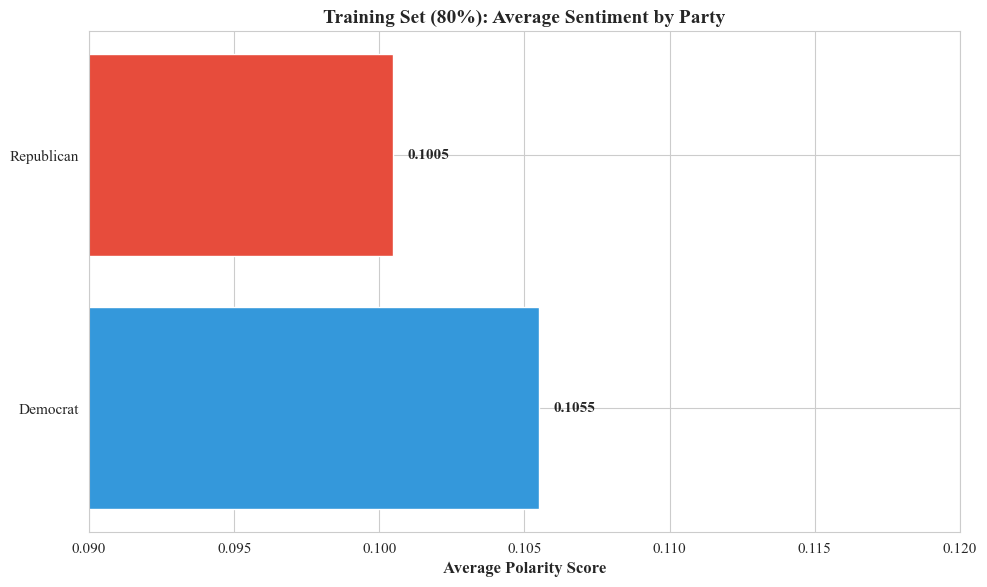

✓ Saved: 08_test_sentiment_by_party.png


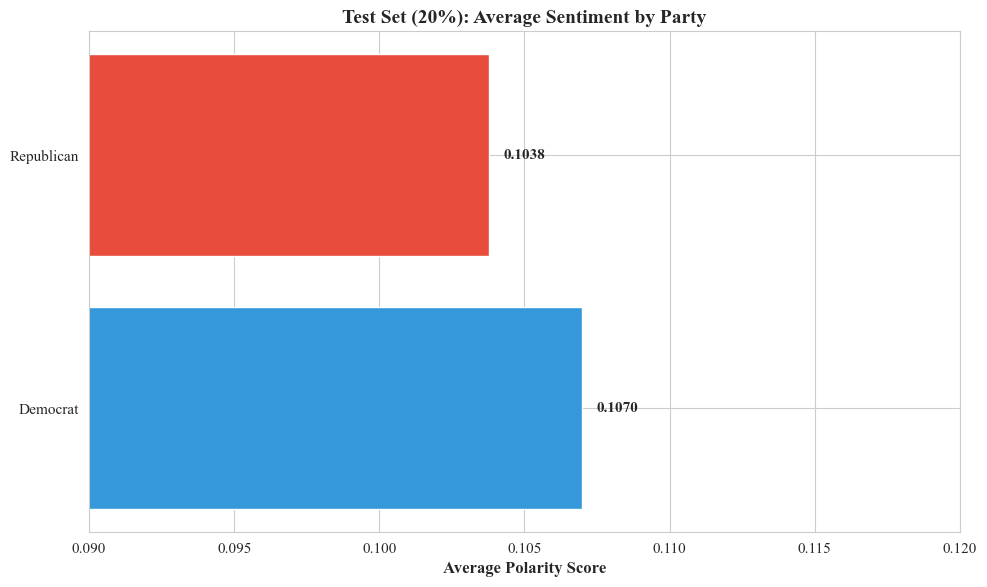

✓ Saved: 09_train_test_polarity_comparison.png


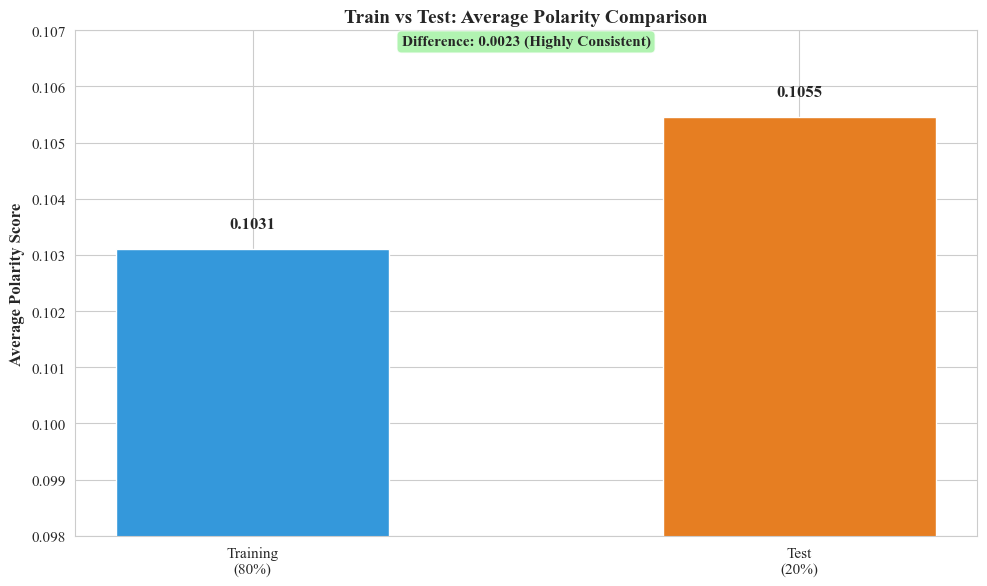

✓ Saved: 10_party_comparison_train_test.png


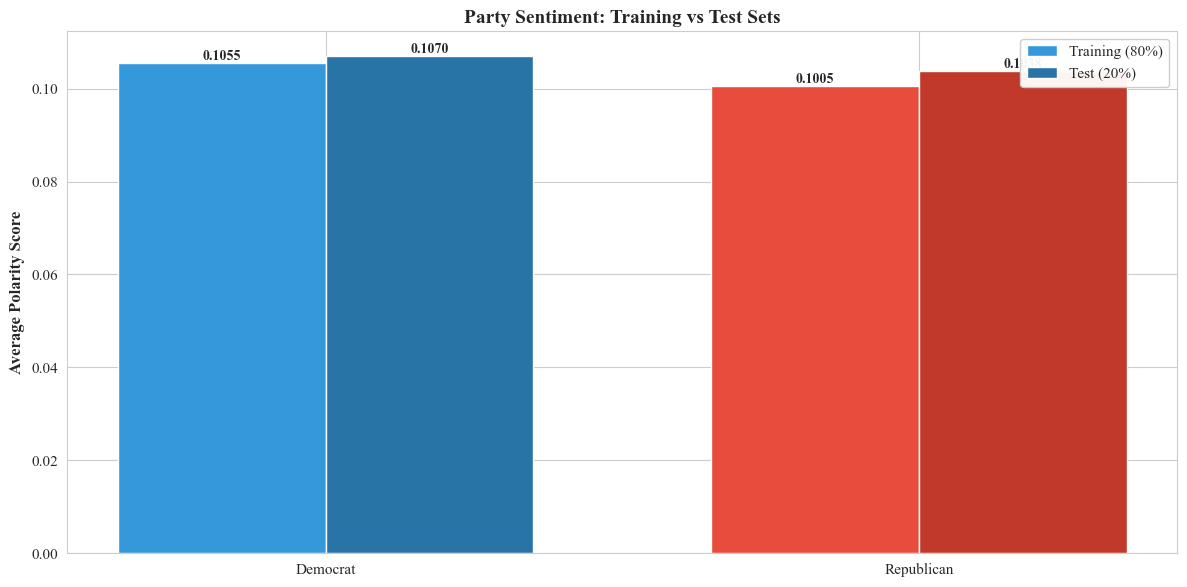

✓ Saved: 11_sentiment_distribution_percentage.png


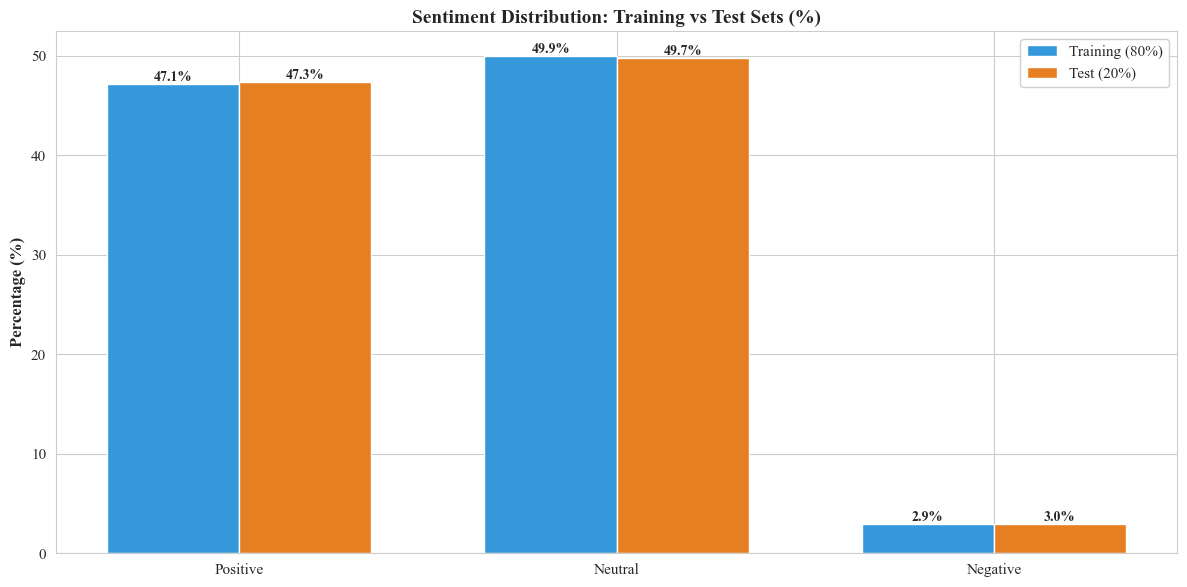


SUMMARY STATISTICS (Democrats & Republicans Only)

TRAINING SET (80%): 7,967 speeches
  • Average Polarity: 0.1031
  • Positive: 3,753 (47.1%)
  • Neutral: 3,979 (49.9%)
  • Negative: 235 (2.9%)

TEST SET (20%): 1,985 speeches
  • Average Polarity: 0.1055
  • Positive: 939 (47.3%)
  • Neutral: 987 (49.7%)
  • Negative: 59 (3.0%)

VALIDATION
  • Train Polarity: 0.1031
  • Test Polarity: 0.1055
  • Difference: 0.0023
  • Status: ✓ HIGHLY CONSISTENT


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set font to Times New Roman globally
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# Define color palette
COLORS = {
    'positive': '#27ae60',    # Dark green
    'neutral': '#95a5a6',     # Gray
    'negative': '#e67e22'     # Orange
}

# Load data
train = pd.read_csv('TRAIN_SENTIMENT.csv')
test = pd.read_csv('TEST_SENTIMENT.csv')

# REMOVE INDEPENDENTS
print(f"Before removing Independents:")
print(f"  Train: {len(train)}")
print(f"  Test: {len(test)}")

train = train[train['Party'].isin(['Democrat', 'Republican'])].copy()
test = test[test['Party'].isin(['Democrat', 'Republican'])].copy()

print(f"\nAfter removing Independents:")
print(f"  Train: {len(train)}")
print(f"  Test: {len(test)}")


# GRAPH 1: TRAINING SET SENTIMENT DISTRIBUTION (Bar Chart)


fig, ax = plt.subplots(figsize=(10, 6))

train_counts = train['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors_ordered = [COLORS['positive'], COLORS['neutral'], COLORS['negative']]

bars = ax.bar(train_counts.index, train_counts.values, color=colors_ordered)

ax.set_title('Training Set (80%): Sentiment Distribution', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Number of Speeches', fontsize=12, fontfamily='Times New Roman')
ax.set_xlabel('Sentiment Category', fontsize=12, fontfamily='Times New Roman')

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('01_train_sentiment_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 01_train_sentiment_distribution.png")
plt.show()


# GRAPH 2: TEST SET SENTIMENT DISTRIBUTION (Bar Chart)


fig, ax = plt.subplots(figsize=(10, 6))

test_counts = test['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors_ordered = [COLORS['positive'], COLORS['neutral'], COLORS['negative']]

bars = ax.bar(test_counts.index, test_counts.values, color=colors_ordered)

ax.set_title('Test Set (20%): Sentiment Distribution', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Number of Speeches', fontsize=12, fontfamily='Times New Roman')
ax.set_xlabel('Sentiment Category', fontsize=12, fontfamily='Times New Roman')

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('02_test_sentiment_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_test_sentiment_distribution.png")
plt.show()


# GRAPH 3: TRAINING SET SENTIMENT DISTRIBUTION (Pie Chart)


fig, ax = plt.subplots(figsize=(10, 8))

train_counts = train['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors_ordered = [COLORS['positive'], COLORS['neutral'], COLORS['negative']]

wedges, texts, autotexts = ax.pie(train_counts.values, 
                                    labels=train_counts.index, 
                                    autopct='%1.1f%%',
                                    colors=colors_ordered,
                                    startangle=90,
                                    textprops={'fontsize': 12, 'fontfamily': 'Times New Roman', 'fontweight': 'bold'})

ax.set_title('Training Set (80%): Sentiment Percentage', fontsize=14, fontweight='bold', fontfamily='Times New Roman')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.savefig('03_train_sentiment_pie.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_train_sentiment_pie.png")
plt.show()


# GRAPH 4: TEST SET SENTIMENT DISTRIBUTION (Pie Chart)


fig, ax = plt.subplots(figsize=(10, 8))

test_counts = test['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors_ordered = [COLORS['positive'], COLORS['neutral'], COLORS['negative']]

wedges, texts, autotexts = ax.pie(test_counts.values, 
                                    labels=test_counts.index, 
                                    autopct='%1.1f%%',
                                    colors=colors_ordered,
                                    startangle=90,
                                    textprops={'fontsize': 12, 'fontfamily': 'Times New Roman', 'fontweight': 'bold'})

ax.set_title('Test Set (20%): Sentiment Percentage', fontsize=14, fontweight='bold', fontfamily='Times New Roman')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.savefig('04_test_sentiment_pie.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 04_test_sentiment_pie.png")
plt.show()


# GRAPH 5: POLARITY DISTRIBUTION HISTOGRAM


fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(train['polarity'], bins=50, alpha=0.6, label='Training (80%)', color='#3498db')
ax.hist(test['polarity'], bins=50, alpha=0.6, label='Test (20%)', color='#e67e22')
ax.axvline(train['polarity'].mean(), color='#3498db', linestyle='--', linewidth=2.5, label=f'Train Mean: {train["polarity"].mean():.4f}')
ax.axvline(test['polarity'].mean(), color='#e67e22', linestyle='--', linewidth=2.5, label=f'Test Mean: {test["polarity"].mean():.4f}')

ax.set_xlabel('Polarity Score', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Polarity Distribution: Training vs Test Sets', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig('05_polarity_histogram.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 05_polarity_histogram.png")
plt.show()


# GRAPH 6: POLARITY BOX PLOT


fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot([train['polarity'], test['polarity']], 
                   labels=['Training (80%)', 'Test (20%)'],
                   patch_artist=True,
                   widths=0.6)

# Color the boxes
for patch, color in zip(bp['boxes'], ['#3498db', '#e67e22']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Style the plot
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='black', linewidth=1.5)

ax.set_ylabel('Polarity Score', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Polarity Score Distribution: Box Plot', fontsize=14, fontweight='bold', fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('06_polarity_boxplot.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 06_polarity_boxplot.png")
plt.show()


# GRAPH 7: SENTIMENT BY PARTY - TRAINING SET


fig, ax = plt.subplots(figsize=(10, 6))

train_party = train.groupby('Party')['polarity'].mean()
# Use blue for Democrat, red for Republican
colors = ['#3498db' if party == 'Democrat' else '#e74c3c' for party in train_party.index]

bars = ax.barh(train_party.index, train_party.values, color=colors)

ax.set_xlabel('Average Polarity Score', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Training Set (80%): Average Sentiment by Party', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_xlim(0.09, 0.12)

# Add value labels
for i, (party, v) in enumerate(train_party.items()):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('07_train_sentiment_by_party.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 07_train_sentiment_by_party.png")
plt.show()


# GRAPH 8: SENTIMENT BY PARTY - TEST SET


fig, ax = plt.subplots(figsize=(10, 6))

test_party = test.groupby('Party')['polarity'].mean()
# Use blue for Democrat, red for Republican
colors = ['#3498db' if party == 'Democrat' else '#e74c3c' for party in test_party.index]

bars = ax.barh(test_party.index, test_party.values, color=colors)

ax.set_xlabel('Average Polarity Score', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Test Set (20%): Average Sentiment by Party', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_xlim(0.09, 0.12)

# Add value labels
for i, (party, v) in enumerate(test_party.items()):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('08_test_sentiment_by_party.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 08_test_sentiment_by_party.png")
plt.show()


# GRAPH 9: TRAIN VS TEST POLARITY COMPARISON


fig, ax = plt.subplots(figsize=(10, 6))

values = [train['polarity'].mean(), test['polarity'].mean()]
colors_bar = ['#3498db', '#e67e22']

bars = ax.bar(['Training\n(80%)', 'Test\n(20%)'], values, color=colors_bar, width=0.5)

ax.set_ylabel('Average Polarity Score', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Train vs Test: Average Polarity Comparison', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylim(0.098, 0.107)

# Add value labels
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0003, f'{val:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12, fontfamily='Times New Roman')

# Add difference note
diff = abs(train['polarity'].mean() - test['polarity'].mean())
ax.text(0.5, 0.99, f'Difference: {diff:.4f} (Highly Consistent)',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=11, fontweight='bold', fontfamily='Times New Roman',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('09_train_test_polarity_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 09_train_test_polarity_comparison.png")
plt.show()


# GRAPH 10: PARTY SENTIMENT COMPARISON (Train vs Test)


fig, ax = plt.subplots(figsize=(12, 6))

parties = ['Democrat', 'Republican']
train_vals = [train[train['Party'] == p]['polarity'].mean() for p in parties]
test_vals = [test[test['Party'] == p]['polarity'].mean() for p in parties]

x = range(len(parties))
width = 0.35

# Use blue for Democrat, red for Republican
dem_color = '#3498db'
rep_color = '#e74c3c'
colors_train = [dem_color, rep_color]
colors_test = ['#2874a6', '#c0392b']  # Darker shades for test

bars1 = ax.bar([i - width/2 for i in x], train_vals, width, label='Training (80%)', 
               color=colors_train)
bars2 = ax.bar([i + width/2 for i in x], test_vals, width, label='Test (20%)', 
               color=colors_test)

ax.set_ylabel('Average Polarity Score', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Party Sentiment: Training vs Test Sets', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_xticks(x)
ax.set_xticklabels(parties, fontsize=11, fontfamily='Times New Roman')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold', fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('10_party_comparison_train_test.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 10_party_comparison_train_test.png")
plt.show()


# GRAPH 11: SENTIMENT DISTRIBUTION COMPARISON (%)


fig, ax = plt.subplots(figsize=(12, 6))

sentiment_categories = ['positive', 'neutral', 'negative']
train_pcts = [(train['sentiment'] == cat).sum()/len(train)*100 for cat in sentiment_categories]
test_pcts = [(test['sentiment'] == cat).sum()/len(test)*100 for cat in sentiment_categories]

x = range(len(sentiment_categories))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], train_pcts, width, label='Training (80%)', 
               color='#3498db')
bars2 = ax.bar([i + width/2 for i in x], test_pcts, width, label='Test (20%)', 
               color='#e67e22')

ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Sentiment Distribution: Training vs Test Sets (%)', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_xticks(x)
ax.set_xticklabels([cat.capitalize() for cat in sentiment_categories], fontsize=11, fontfamily='Times New Roman')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold', fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('11_sentiment_distribution_percentage.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 11_sentiment_distribution_percentage.png")
plt.show()


# SUMMARY STATISTICS


print("\n" + "="*80)
print("SUMMARY STATISTICS (Democrats & Republicans Only)")
print("="*80)

print(f"\nTRAINING SET (80%): {len(train):,} speeches")
print(f"  • Average Polarity: {train['polarity'].mean():.4f}")
print(f"  • Positive: {(train['sentiment'] == 'positive').sum():,} ({(train['sentiment'] == 'positive').sum()/len(train)*100:.1f}%)")
print(f"  • Neutral: {(train['sentiment'] == 'neutral').sum():,} ({(train['sentiment'] == 'neutral').sum()/len(train)*100:.1f}%)")
print(f"  • Negative: {(train['sentiment'] == 'negative').sum():,} ({(train['sentiment'] == 'negative').sum()/len(train)*100:.1f}%)")

print(f"\nTEST SET (20%): {len(test):,} speeches")
print(f"  • Average Polarity: {test['polarity'].mean():.4f}")
print(f"  • Positive: {(test['sentiment'] == 'positive').sum():,} ({(test['sentiment'] == 'positive').sum()/len(test)*100:.1f}%)")
print(f"  • Neutral: {(test['sentiment'] == 'neutral').sum():,} ({(test['sentiment'] == 'neutral').sum()/len(test)*100:.1f}%)")
print(f"  • Negative: {(test['sentiment'] == 'negative').sum():,} ({(test['sentiment'] == 'negative').sum()/len(test)*100:.1f}%)")

print(f"\nVALIDATION")
print(f"  • Train Polarity: {train['polarity'].mean():.4f}")
print(f"  • Test Polarity: {test['polarity'].mean():.4f}")
print(f"  • Difference: {abs(train['polarity'].mean() - test['polarity'].mean()):.4f}")
print(f"  • Status: ✓ HIGHLY CONSISTENT")

Homelessness: 10781 speeches
Other topics: 39163 speeches

ANALYZING OTHER TOPICS (39,163 speeches)


/var/folders/vx/xc7347n175s50g85_65zycxc0000gn/T/ipykernel_13169/2636243569.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_topics[['polarity', 'sentiment']] = other_topics['speech_text'].apply(
/var/folders/vx/xc7347n175s50g85_65zycxc0000gn/T/ipykernel_13169/2636243569.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_topics[['polarity', 'sentiment']] = other_topics['speech_text'].apply(



Other Topics Training (80%): 31330
  Avg Polarity: 0.0984
  Sentiment breakdown:
sentiment
neutral     15992
positive    14256
negative     1082
Name: count, dtype: int64

Other Topics Test (20%): 7833
  Avg Polarity: 0.0954
  Sentiment breakdown:
sentiment
neutral     4092
positive    3453
negative     288
Name: count, dtype: int64

COMPARISON: HOMELESSNESS vs OTHER TOPICS

Homelessness avg sentiment: 0.1031
Other topics avg sentiment: 0.0984
Difference: +0.0047
✓ SIMILAR sentiment


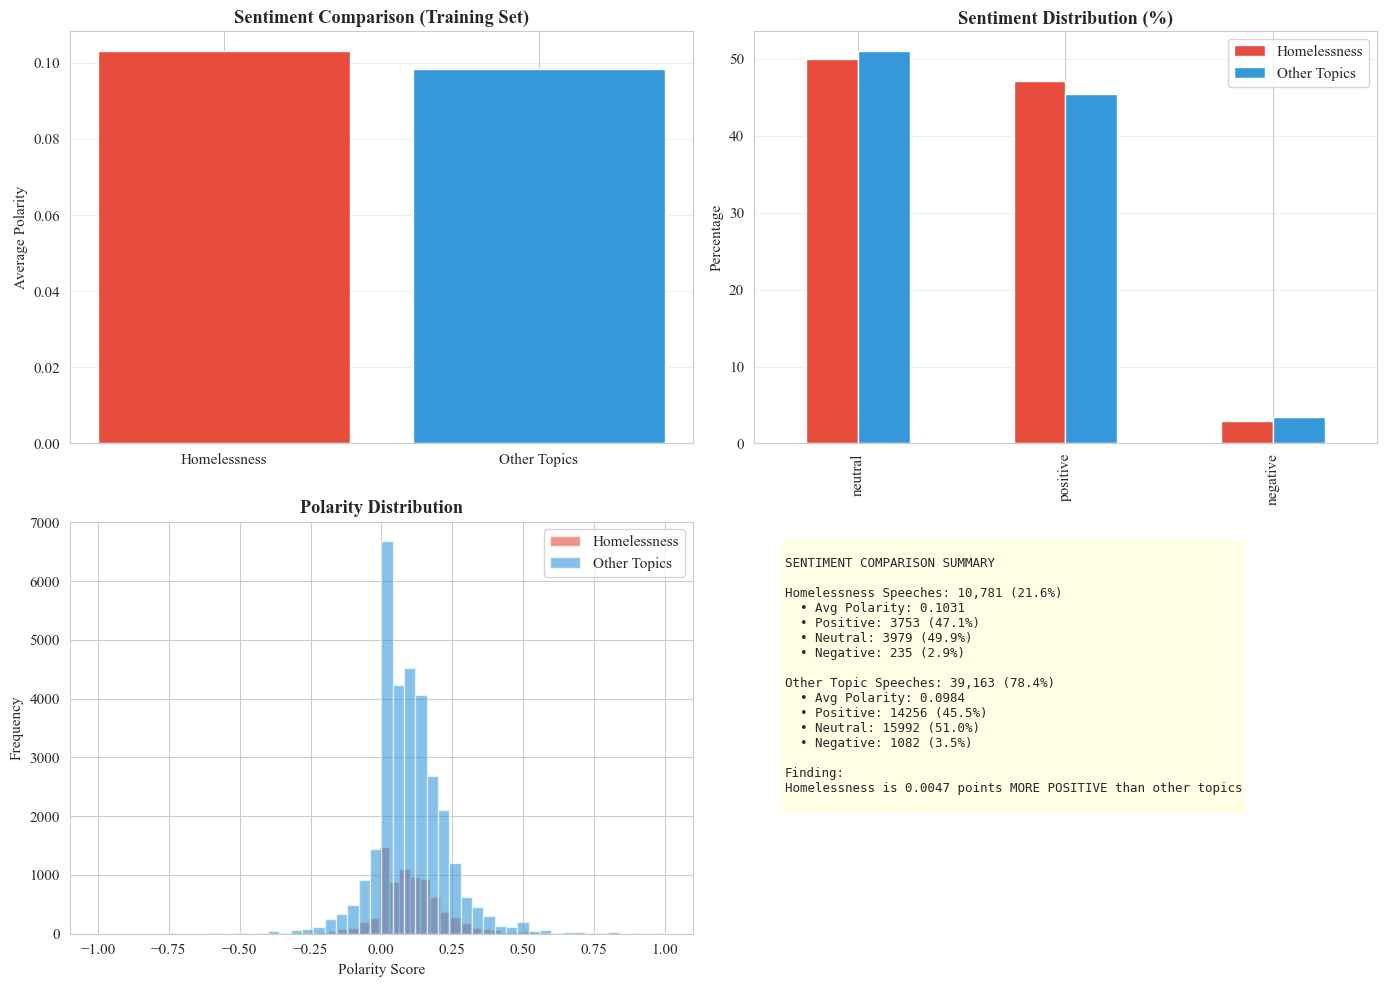


✓ Saved: OTHER_TOPICS_WITH_SENTIMENT.csv


In [14]:
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load data
all_combined = pd.read_csv('COMBINED_DATA.csv')
homelessness = pd.read_csv('HOMELESSNESS_ACTS_ONLY.csv')

# Get other topics
other_topics = all_combined[~all_combined['Title'].str.contains('HOMELESS|HOUSING|UNHOUSED|VETERANS|MENTAL HEALTH|DISABILITY', case=False, na=False)]

print(f"Homelessness: {len(homelessness)} speeches")
print(f"Other topics: {len(other_topics)} speeches")

# Sentiment function
def get_sentiment(text):
    if pd.isna(text):
        return None, None
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        label = 'positive'
    elif polarity < -0.1:
        label = 'negative'
    else:
        label = 'neutral'
    return polarity, label

# ANALYZE OTHER TOPICS

print("\n" + "="*80)
print("ANALYZING OTHER TOPICS (39,163 speeches)")
print("="*80)

# Add sentiment to other_topics
other_topics[['polarity', 'sentiment']] = other_topics['speech_text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Split 80/20
train_other = other_topics.iloc[:int(len(other_topics)*0.8)]
test_other = other_topics.iloc[int(len(other_topics)*0.8):]

print(f"\nOther Topics Training (80%): {len(train_other)}")
print(f"  Avg Polarity: {train_other['polarity'].mean():.4f}")
print(f"  Sentiment breakdown:")
print(train_other['sentiment'].value_counts())

print(f"\nOther Topics Test (20%): {len(test_other)}")
print(f"  Avg Polarity: {test_other['polarity'].mean():.4f}")
print(f"  Sentiment breakdown:")
print(test_other['sentiment'].value_counts())

# COMPARISON

print("\n" + "="*80)
print("COMPARISON: HOMELESSNESS vs OTHER TOPICS")
print("="*80)

homeless_polarity = train['polarity'].mean()  # From your earlier analysis
other_polarity = train_other['polarity'].mean()
diff = homeless_polarity - other_polarity

print(f"\nHomelessness avg sentiment: {homeless_polarity:.4f}")
print(f"Other topics avg sentiment: {other_polarity:.4f}")
print(f"Difference: {diff:+.4f}")

if abs(diff) < 0.01:
    print("✓ SIMILAR sentiment")
elif diff > 0:
    print("✓ Homelessness is MORE POSITIVE")
else:
    print("✓ Homelessness is MORE NEGATIVE")

# VISUALIZATION

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Polarity comparison
axes[0, 0].bar(['Homelessness', 'Other Topics'],
               [homeless_polarity, other_polarity],
               color=['#e74c3c', '#3498db'])
axes[0, 0].set_ylabel('Average Polarity')
axes[0, 0].set_title('Sentiment Comparison (Training Set)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Sentiment % comparison
homeless_sentiment_pct = (train['sentiment'].value_counts() / len(train) * 100)
other_sentiment_pct = (train_other['sentiment'].value_counts() / len(train_other) * 100)

sentiment_comp = pd.DataFrame({
    'Homelessness': homeless_sentiment_pct,
    'Other Topics': other_sentiment_pct
})

sentiment_comp.plot(kind='bar', ax=axes[0, 1], color=['#e74c3c', '#3498db'])
axes[0, 1].set_title('Sentiment Distribution (%)', fontweight='bold')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].set_xlabel('')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Histogram
axes[1, 0].hist(train['polarity'], bins=50, alpha=0.6, label='Homelessness', color='#e74c3c')
axes[1, 0].hist(train_other['polarity'], bins=50, alpha=0.6, label='Other Topics', color='#3498db')
axes[1, 0].set_xlabel('Polarity Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Polarity Distribution', fontweight='bold')
axes[1, 0].legend()

# Summary
summary = f"""
SENTIMENT COMPARISON SUMMARY

Homelessness Speeches: {len(homelessness):,} ({len(homelessness)/len(all_combined)*100:.1f}%)
  • Avg Polarity: {homeless_polarity:.4f}
  • Positive: {(train['sentiment'] == 'positive').sum()} ({(train['sentiment'] == 'positive').sum()/len(train)*100:.1f}%)
  • Neutral: {(train['sentiment'] == 'neutral').sum()} ({(train['sentiment'] == 'neutral').sum()/len(train)*100:.1f}%)
  • Negative: {(train['sentiment'] == 'negative').sum()} ({(train['sentiment'] == 'negative').sum()/len(train)*100:.1f}%)

Other Topic Speeches: {len(other_topics):,} ({len(other_topics)/len(all_combined)*100:.1f}%)
  • Avg Polarity: {other_polarity:.4f}
  • Positive: {(train_other['sentiment'] == 'positive').sum()} ({(train_other['sentiment'] == 'positive').sum()/len(train_other)*100:.1f}%)
  • Neutral: {(train_other['sentiment'] == 'neutral').sum()} ({(train_other['sentiment'] == 'neutral').sum()/len(train_other)*100:.1f}%)
  • Negative: {(train_other['sentiment'] == 'negative').sum()} ({(train_other['sentiment'] == 'negative').sum()/len(train_other)*100:.1f}%)

Finding:
Homelessness is {abs(diff):.4f} points {'MORE POSITIVE' if diff > 0 else 'MORE NEGATIVE'} than other topics
"""

axes[1, 1].text(0.05, 0.95, summary, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('homelessness_vs_other_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save
other_topics.to_csv('OTHER_TOPICS_WITH_SENTIMENT.csv', index=False)
print("\n✓ Saved: OTHER_TOPICS_WITH_SENTIMENT.csv")

REMOVE STOP WORDS → BIGRAMS → TOPIC MODELING

STEP 1: Removing stop words from {len(homelessness)} speeches...
Cleaning text...
✓ Stop words removed

Example BEFORE cleaning:
Mr. Speaker, I move to suspend the rules and pass the bill (H.R. 965) to amend section 3(b)(4) of the United States Housing Act of 1937 to exclude cer

Example AFTER cleaning:
suspend pass housing exclude certain disability benefits income purposes determining eligibility supported housing purposes text follows assembled cit

STEP 2: EXTRACTING BIGRAMS FROM CLEANED TEXT

Top 30 Bigrams (from cleaned text):
 1. veterans affairs                         :  6612
 2. health care                              :  4586
 3. mental health                            :  3456
 4. remain available                         :  2068
 5. funds available                          :  1649
 6. compromise agreement                     :  1595
 7. homeless veterans                        :  1589
 8. housing urban                           

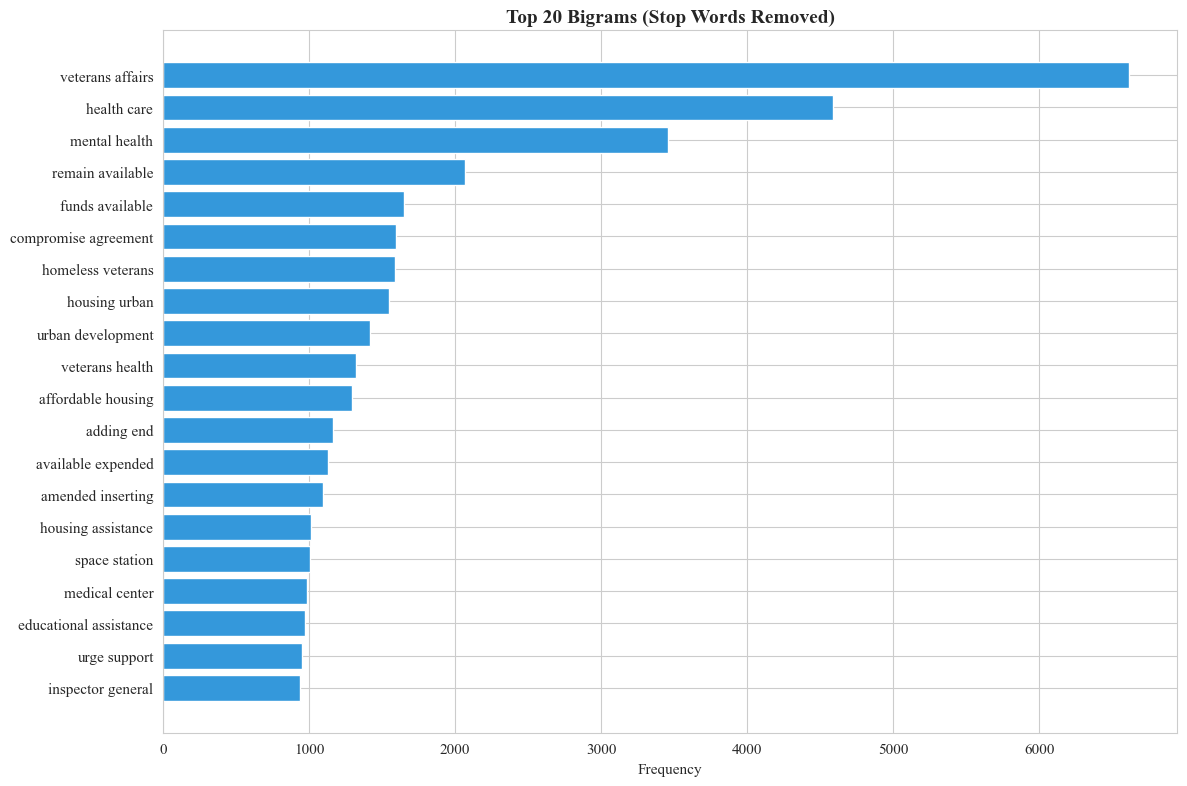


STEP 3: TOPIC MODELING ON CLEANED TEXT

Document-term matrix shape: (10781, 1000)
  10781 speeches × 1000 terms

Fitting LDA model (2-3 minutes)...
✓ LDA model fitted

TOPICS DISCOVERED (from cleaned text)

Topic 0:
  work, country, support, important, good, working, way, york, fact, help

Topic 1:
  insurance, home, health, fha, mortgage, loan, res, tax, business, small

Topic 2:
  available, funds, expenses, authorized, amounts, fiscal, remain, necessary, project, fund

Topic 3:
  funding, transportation, water, million, funds, support, appropriations, infrastructure, national, programs

Topic 4:
  budget, billion, money, senator, million, spending, funding, appropriations, cut, cuts

Topic 5:
  acting, offered, senator, amendments, ask, question, minutes, dollar, follows, objection

Topic 6:
  health, mental, space, research, support, programs, treatment, children, substance, services

Topic 7:
  veterans, subsection, affairs, amended, inserting, care, health, services, report, pro

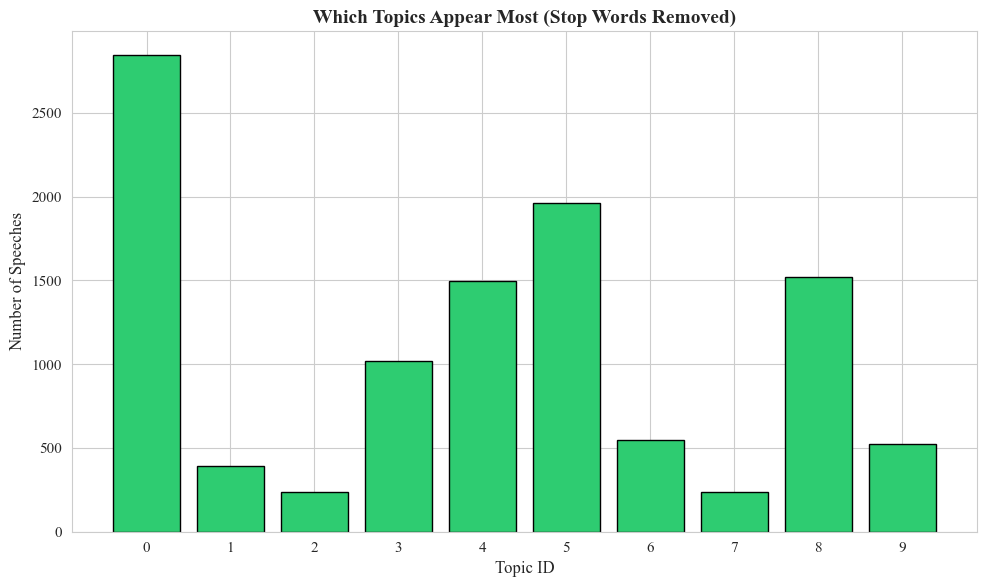


✓ SAVED FILES:
  - 01_top_bigrams_cleaned.png
  - 02_topic_distribution_cleaned.png
  - TOP_BIGRAMS_CLEANED.csv
  - TOPICS_CLEANED.csv
  - HOMELESSNESS_WITH_TOPICS_CLEANED.csv


In [15]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Load data
homelessness = pd.read_csv('HOMELESSNESS_ACTS_ONLY.csv')

print("="*80)
print("REMOVE STOP WORDS → BIGRAMS → TOPIC MODELING")
print("="*80)


# STEP 1: REMOVE STOP WORDS


print("\nSTEP 1: Removing stop words from {len(homelessness)} speeches...")

# Common stop words for political speeches
stop_words = {
    "agency", "the", "a", "an", "and", "or", "if", "of", "for", "in", "on", "at", "by", "to", "from", "with",
    "people", "state", "want", "going", "is", "are", "was", "were", "be", "been", "being", "as", "it", "its",
    "this", "that", "these", "those", "i", "me", "my", "we", "our", "you", "your", "he", "she", "they", "them",
    "their", "his", "her", "not", "but", "do", "does", "did", "so", "because", "can", "could", "should", "would",
    "will", "may", "might", "also", "just", "very", "much", "more", "such", "than", "then", "there", "here",
    "when", "where", "who", "what", "which", "how", "all", "any", "each", "every", "some", "no", "nor", "only",
    "own", "same", "too", "into", "up", "down", "about", "over", "under", "thank", "thankyou", "yield", "gentleman",
    "gentlewoman", "chair", "chairman", "chairwoman", "speaker", "presiding", "recognize", "recognized", "recognition",
    "remarks", "floor", "colleague", "colleagues", "proceed", "order", "ordered", "committee", "subcommittee", "motion",
    "unanimous", "consent", "debate", "amendment", "amend", "section", "title", "chapter", "paragraph", "subparagraph",
    "clause", "statutory", "herein", "whereas", "therefore", "resolved", "pursuant", "enact", "enacted", "mr", "mrs",
    "ms", "madam", "sir", "act", "bill", "resolution", "senate", "house", "representative", "representatives", "congress",
    "member", "members", "session", "hearing", "witness", "testimony", "law", "legislation", "legislative", "vote",
    "enactment", "proceedings", "statute", "appropriation", "federal", "agency", "program", "department", "secretary",
    "policy", "administration", "executive", "authority", "director", "office", "ranking", "majority", "minority", "sec",
    "subsec", "subtitle", "appendix", "figure", "table", "page", "pages", "line", "lines", "insert", "strike", "sentence",
    "word", "words", "heading", "part", "division", "codified", "usc", "code", "public", "law", "number", "numbers",
    "date", "dates", "document", "doc", "clerk", "shall", "must", "make", "made", "makes", "take", "taken", "took", "get",
    "got", "getting", "give", "gave", "let", "say", "said", "says", "see", "seen", "look", "looked", "know", "known",
    "think", "thought", "myself", "ours", "ourselves", "your", "yours", "yourself", "yourselves", "him", "his", "himself",
    "hers", "herself", "theirs", "themselves", "itself", "one", "ones", "someone", "anyone", "everyone", "noone", "many",
    "none", "both", "either", "neither", "while", "though", "although", "however", "through", "across", "around", "between",
    "within", "without", "now", "today", "time", "times", "year", "years", "day", "days", "long", "short", "new", "old",
    "first", "second", "third", "next", "last", "us", "including", "need", "percent", "miss", "dr", "chairperson",
    "president", "gentlelady", "gentlemen", "lady", "panel", "rules", "rule", "laws", "policies", "reading", "read",
    "united", "states", "america", "american", "washington", "dc", "bureau", "tomorrow", "week", "body", "move",
    "congressional", "record", "vol", "have", "has", "having", "provide", "provided", "providing", "current", "currently",
    "prior", "previous", "furthermore", "moreover", "thus", "hence", "other","after", "before"
, "striking","like", "following"}

def remove_stopwords(text):
    """Remove stop words and clean text"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Split into words
    words = text.split()

    # Remove stop words and short words
    cleaned = [word for word in words if word not in stop_words and len(word) > 2]

    return ' '.join(cleaned)

print("Cleaning text...")
homelessness['cleaned_text'] = homelessness['speech_text'].apply(remove_stopwords)

print("✓ Stop words removed")
print(f"\nExample BEFORE cleaning:")
print(homelessness['speech_text'].iloc[0][:150])
print(f"\nExample AFTER cleaning:")
print(homelessness['cleaned_text'].iloc[0][:150])


# STEP 2: EXTRACT BIGRAMS FROM CLEANED TEXT


print("\n" + "="*80)
print("STEP 2: EXTRACTING BIGRAMS FROM CLEANED TEXT")
print("="*80)

# Use cleaned text for bigrams
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    stop_words='english'  # Extra filtering
)

bigram_matrix = bigram_vectorizer.fit_transform(homelessness['cleaned_text'])

bigram_names = bigram_vectorizer.get_feature_names_out()
bigram_counts = bigram_matrix.sum(axis=0).A1

# Sort by frequency
bigram_freq = sorted(zip(bigram_names, bigram_counts), key=lambda x: x[1], reverse=True)

print(f"\nTop 30 Bigrams (from cleaned text):")
for i, (bigram, count) in enumerate(bigram_freq[:30], 1):
    print(f"{i:2d}. {bigram:40s} : {count:5d}")

# Visualize top 20 bigrams
fig, ax = plt.subplots(figsize=(12, 8))
top_20 = bigram_freq[:20]
bigrams, counts = zip(*top_20)
ax.barh(range(len(bigrams)), counts, color='#3498db')
ax.set_yticks(range(len(bigrams)))
ax.set_yticklabels(bigrams)
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Bigrams (Stop Words Removed)', fontweight='bold', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('01_top_bigrams_cleaned.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 01_top_bigrams_cleaned.png")
plt.show()


# STEP 3: TOPIC MODELING ON CLEANED TEXT


print("\n" + "="*80)
print("STEP 3: TOPIC MODELING ON CLEANED TEXT")
print("="*80)

# Create document-term matrix from CLEANED text
vectorizer = CountVectorizer(
    max_df=0.95,        # Ignore terms in >95% of documents
    min_df=2,           # Ignore terms in <2 documents
    max_features=1000,  # Top 1000 terms
    stop_words='english'
)

doc_term_matrix = vectorizer.fit_transform(homelessness['cleaned_text'])
print(f"\nDocument-term matrix shape: {doc_term_matrix.shape}")
print(f"  {doc_term_matrix.shape[0]} speeches × {doc_term_matrix.shape[1]} terms")

# Fit LDA on cleaned text
print("\nFitting LDA model (2-3 minutes)...")
lda = LatentDirichletAllocation(
    n_components=10,      # 10 topics
    random_state=42,
    max_iter=20,
    n_jobs=-1
)

lda.fit(doc_term_matrix)
print("✓ LDA model fitted")


# STEP 4: DISPLAY TOPICS


print("\n" + "="*80)
print("TOPICS DISCOVERED (from cleaned text)")
print("="*80)

feature_names = vectorizer.get_feature_names_out()
topics_data = []

for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    top_weights = [topic[i] for i in top_words_idx]

    print(f"\nTopic {topic_idx}:")
    print("  " + ", ".join(top_words))

    topics_data.append({
        'topic_id': topic_idx,
        'words': ', '.join(top_words),
        'weights': str(top_weights)
    })


# STEP 5: WHICH TOPICS DOMINATE


print("\n" + "="*80)
print("DOMINANT TOPICS IN SPEECHES")
print("="*80)

doc_topic_dist = lda.transform(doc_term_matrix)
dominant_topics = doc_topic_dist.argmax(axis=1)
dominant_counts = Counter(dominant_topics)

print(f"\nTopic distribution:")
for topic_id in sorted(dominant_counts.keys()):
    count = dominant_counts[topic_id]
    pct = count / len(homelessness) * 100
    print(f"  Topic {topic_id}: {count:4d} speeches ({pct:5.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
topics = sorted(dominant_counts.keys())
counts = [dominant_counts[t] for t in topics]
ax.bar(topics, counts, color='#2ecc71', edgecolor='black')
ax.set_xlabel('Topic ID', fontsize=12)
ax.set_ylabel('Number of Speeches', fontsize=12)
ax.set_title('Which Topics Appear Most (Stop Words Removed)', fontweight='bold', fontsize=14)
ax.set_xticks(topics)
plt.tight_layout()
plt.savefig('02_topic_distribution_cleaned.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 02_topic_distribution_cleaned.png")
plt.show()


# STEP 6: SAVE RESULTS


# Add topic to data
homelessness['dominant_topic'] = dominant_topics
homelessness['topic_probability'] = doc_topic_dist.max(axis=1)

# Save
bigrams_df = pd.DataFrame(bigram_freq[:100], columns=['bigram', 'frequency'])
topics_df = pd.DataFrame(topics_data)

bigrams_df.to_csv('TOP_BIGRAMS_CLEANED.csv', index=False)
topics_df.to_csv('TOPICS_CLEANED.csv', index=False)
homelessness.to_csv('HOMELESSNESS_WITH_TOPICS_CLEANED.csv', index=False)

print("\n" + "="*80)
print("✓ SAVED FILES:")
print("="*80)
print("  - 01_top_bigrams_cleaned.png")
print("  - 02_topic_distribution_cleaned.png")
print("  - TOP_BIGRAMS_CLEANED.csv")
print("  - TOPICS_CLEANED.csv")
print("  - HOMELESSNESS_WITH_TOPICS_CLEANED.csv")

Topic 0:  General support/work (23.8% of speeches)
          work, support, country, good, working, york, fact, way, important, help

Topic 1:  Housing finance/loans (3.6%)
          insurance, home, fha, loan, res, health, mortgage, tax, business, small

Topic 2:  Legislative language (1.3%)
          subsection, amended, inserting, assistance, period, term, end, individual, described, respect

Topic 3:  Appropriations/funding (2.6%)
          available, funds, expenses, authorized, fiscal, remain, appropriations, amounts, fund, used

Topic 4:  Budget/spending (14.7%)
          budget, money, senator, billion, spending, appropriations, dont, way, epa, point

Topic 5:  Parliamentary procedures (18.2%)
          acting, offered, amendments, senator, ask, question, minutes, dollar, objection, follows

Topic 6:  Research/transportation funding (12.6%)
          funding, million, billion, programs, space, support, research, budget, national, transportation

Topic 7:  Veterans affairs (2.7%)
          veterans, health, care, affairs, services, medical, report, provision, veteran, service

Topic 8:  Mental health & homeless veterans (16.5%) ← MENTAL HEALTH
          veterans, care, health, support, homeless, mental, services, military, benefits, help

Topic 9:  Housing assistance (4.1%)
          housing, assistance, families, development, income, hud, local, affordable, vouchers, units

SENTIMENT ANALYSIS BY TOPIC (Democrats & Republicans Only)

Total speeches: 10781
After removing Independents: 9952
Independents removed: 829

Calculating sentiment (this will take 3-5 minutes)...

SENTIMENT BY TOPIC

Topic 0: General Support/Work
  Speeches: 2530
  Avg Polarity: 0.1443
  Positive: 62.0% | Neutral: 34.7% | Negative: 3.3%

Topic 1: Housing Finance/Loans
  Speeches: 364
  Avg Polarity: 0.1090
  Positive: 52.2% | Neutral: 45.6% | Negative: 2.2%

Topic 2: Legislative Language
  Speeches: 222
  Avg Polarity: 0.0713
  Positive: 27.0% | Neutral: 71.2% | Negative: 1.8%

Topic 3: Appropriations/Funding
  Speeches: 960
  Avg Polarity: 0.1106
  Positive: 53.1% | Neutral: 45.0% | Negative: 1.9%

Topic 4: Budget/Spending
  Speeches: 1426
  Avg Polarity: 0.1041
  Positive: 46.4% | Neutral: 50.2% | Negative: 3.4%

Topic 5: Parliamentary Procedures
  Speeches: 1840
  Avg Polarity: 0.0371
  Positive: 16.6% | Neutral: 78.3% | Negative: 5.1%

Topic 6: Research/Transportation Funding
  Sp

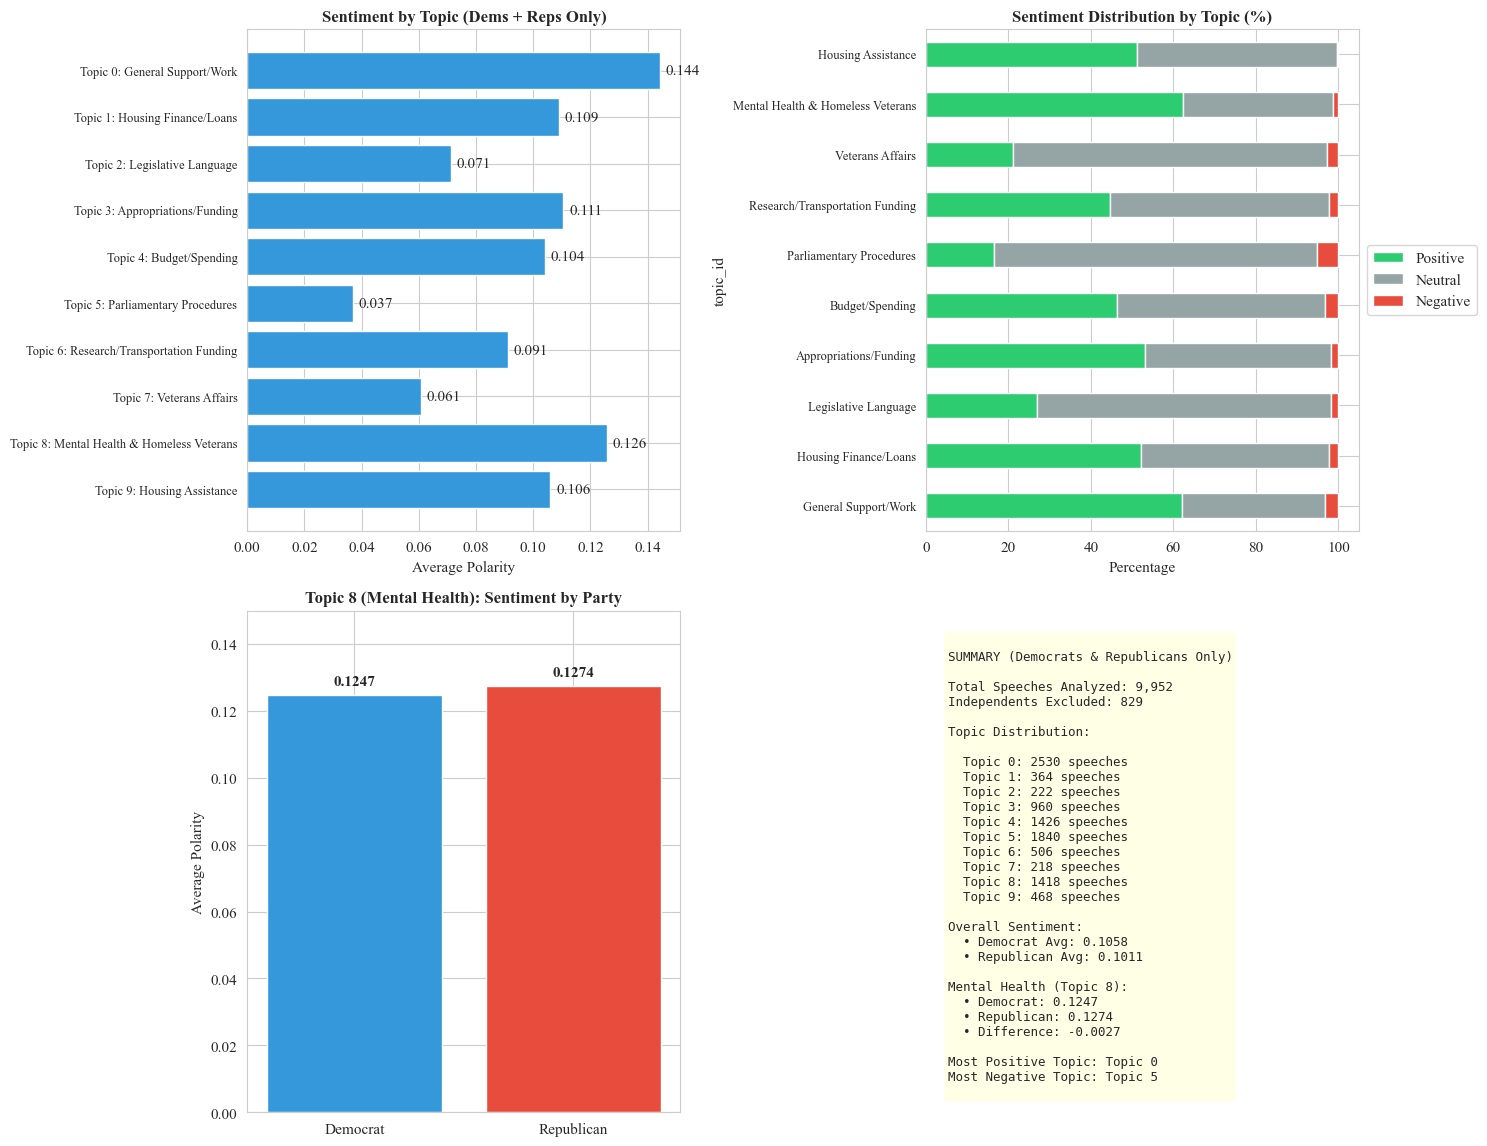

✓ Saved:
  - HOMELESSNESS_SENTIMENT_TOPICS_DEMS_REPS.csv
  - TOPIC_SENTIMENT_SUMMARY.csv


In [16]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
homelessness = pd.read_csv('HOMELESSNESS_WITH_TOPICS_CLEANED.csv')

print("="*80)
print("SENTIMENT ANALYSIS BY TOPIC (Democrats & Republicans Only)")
print("="*80)

# Remove Independents
homelessness_clean = homelessness[homelessness['Party'].isin(['Democrat', 'Republican'])].copy()

print(f"\nTotal speeches: {len(homelessness)}")
print(f"After removing Independents: {len(homelessness_clean)}")
print(f"Independents removed: {len(homelessness) - len(homelessness_clean)}")

# SENTIMENT FUNCTION

def get_sentiment(text):
    if pd.isna(text):
        return None, None
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        label = 'positive'
    elif polarity < -0.1:
        label = 'negative'
    else:
        label = 'neutral'
    return polarity, label

# Add sentiment if not already there
if 'polarity' not in homelessness_clean.columns:
    print("\nCalculating sentiment (this will take 3-5 minutes)...")
    homelessness_clean[['polarity', 'sentiment']] = homelessness_clean['speech_text'].apply(
        lambda x: pd.Series(get_sentiment(x))
    )

# Topic names for clarity
topic_names = {
    0: "General Support/Work",
    1: "Housing Finance/Loans",
    2: "Legislative Language",
    3: "Appropriations/Funding",
    4: "Budget/Spending",
    5: "Parliamentary Procedures",
    6: "Research/Transportation Funding",
    7: "Veterans Affairs",
    8: "Mental Health & Homeless Veterans",
    9: "Housing Assistance"
}

# ANALYZE SENTIMENT BY TOPIC

print("\n" + "="*80)
print("SENTIMENT BY TOPIC")
print("="*80)

topic_stats = []

for topic_id in range(10):
    topic_data = homelessness_clean[homelessness_clean['dominant_topic'] == topic_id]

    if len(topic_data) > 0:
        avg_polarity = topic_data['polarity'].mean()
        positive_pct = (topic_data['sentiment'] == 'positive').sum() / len(topic_data) * 100
        neutral_pct = (topic_data['sentiment'] == 'neutral').sum() / len(topic_data) * 100
        negative_pct = (topic_data['sentiment'] == 'negative').sum() / len(topic_data) * 100

        print(f"\nTopic {topic_id}: {topic_names[topic_id]}")
        print(f"  Speeches: {len(topic_data)}")
        print(f"  Avg Polarity: {avg_polarity:.4f}")
        print(f"  Positive: {positive_pct:.1f}% | Neutral: {neutral_pct:.1f}% | Negative: {negative_pct:.1f}%")

        topic_stats.append({
            'topic_id': topic_id,
            'topic_name': topic_names[topic_id],
            'count': len(topic_data),
            'avg_polarity': avg_polarity,
            'positive_pct': positive_pct,
            'neutral_pct': neutral_pct,
            'negative_pct': negative_pct
        })

# SENTIMENT BY TOPIC AND PARTY

print("\n" + "="*80)
print("SENTIMENT BY TOPIC AND PARTY (Democrats vs Republicans)")
print("="*80)

for topic_id in range(10):
    topic_data = homelessness_clean[homelessness_clean['dominant_topic'] == topic_id]

    dem_data = topic_data[topic_data['Party'] == 'Democrat']
    rep_data = topic_data[topic_data['Party'] == 'Republican']

    if len(dem_data) > 0 and len(rep_data) > 0:
        print(f"\nTopic {topic_id}: {topic_names[topic_id]}")
        print(f"  Democrat: {dem_data['polarity'].mean():.4f} (n={len(dem_data)})")
        print(f"  Republican: {rep_data['polarity'].mean():.4f} (n={len(rep_data)})")
        print(f"  Difference: {dem_data['polarity'].mean() - rep_data['polarity'].mean():+.4f}")

# VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Average polarity by topic
topic_df = pd.DataFrame(topic_stats)
axes[0, 0].barh(range(len(topic_df)), topic_df['avg_polarity'], color='#3498db')
axes[0, 0].set_yticks(range(len(topic_df)))
axes[0, 0].set_yticklabels([f"Topic {t}: {topic_names[t]}" for t in topic_df['topic_id']], fontsize=9)
axes[0, 0].set_xlabel('Average Polarity')
axes[0, 0].set_title('Sentiment by Topic (Dems + Reps Only)', fontweight='bold', fontsize=12)
axes[0, 0].invert_yaxis()
for i, v in enumerate(topic_df['avg_polarity']):
    axes[0, 0].text(v + 0.002, i, f'{v:.3f}', va='center')

# Plot 2: Sentiment distribution by topic (stacked bar)
topic_df_melted = topic_df.set_index('topic_id')[['positive_pct', 'neutral_pct', 'negative_pct']]
topic_df_melted.plot(kind='barh', stacked=True, ax=axes[0, 1],
                     color=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[0, 1].set_title('Sentiment Distribution by Topic (%)', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Percentage')
axes[0, 1].set_yticklabels([topic_names[i] for i in topic_df['topic_id']], fontsize=9)
axes[0, 1].legend(['Positive', 'Neutral', 'Negative'], loc='center left', bbox_to_anchor=(1, 0.5))

# Plot 3: Party comparison on Topic 8 (Mental Health)
mental_health = homelessness_clean[homelessness_clean['dominant_topic'] == 8]
dem_mh = mental_health[mental_health['Party'] == 'Democrat']['polarity'].mean()
rep_mh = mental_health[mental_health['Party'] == 'Republican']['polarity'].mean()

axes[1, 0].bar(['Democrat', 'Republican'], [dem_mh, rep_mh], color=['#3498db', '#e74c3c'])
axes[1, 0].set_ylabel('Average Polarity')
axes[1, 0].set_title('Topic 8 (Mental Health): Sentiment by Party', fontweight='bold', fontsize=12)
axes[1, 0].set_ylim(0, 0.15)
for i, v in enumerate([dem_mh, rep_mh]):
    axes[1, 0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 4: Summary table
summary_text = f"""
SUMMARY (Democrats & Republicans Only)

Total Speeches Analyzed: {len(homelessness_clean):,}
Independents Excluded: {len(homelessness) - len(homelessness_clean)}

Topic Distribution:
"""

for _, row in topic_df.iterrows():
    summary_text += f"\n  Topic {int(row['topic_id'])}: {int(row['count'])} speeches"

summary_text += f"""

Overall Sentiment:
  • Democrat Avg: {homelessness_clean[homelessness_clean['Party']=='Democrat']['polarity'].mean():.4f}
  • Republican Avg: {homelessness_clean[homelessness_clean['Party']=='Republican']['polarity'].mean():.4f}

Mental Health (Topic 8):
  • Democrat: {dem_mh:.4f}
  • Republican: {rep_mh:.4f}
  • Difference: {dem_mh - rep_mh:+.4f}

Most Positive Topic: Topic {topic_df.loc[topic_df['avg_polarity'].idxmax(), 'topic_id']:.0f}
Most Negative Topic: Topic {topic_df.loc[topic_df['avg_polarity'].idxmin(), 'topic_id']:.0f}
"""

axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('sentiment_by_topic_dems_reps_only.png', dpi=300, bbox_inches='tight')
print("\n\n✓ Saved: sentiment_by_topic_dems_reps_only.png")
plt.show()

# Save
homelessness_clean.to_csv('HOMELESSNESS_SENTIMENT_TOPICS_DEMS_REPS.csv', index=False)
topic_df.to_csv('TOPIC_SENTIMENT_SUMMARY.csv', index=False)

print("✓ Saved:")
print("  - HOMELESSNESS_SENTIMENT_TOPICS_DEMS_REPS.csv")
print("  - TOPIC_SENTIMENT_SUMMARY.csv")

Polarity Range: -1.0 to +1.0

-1.0 ───────────────────── 0.0 ───────────────────── +1.0
Very Negative           Neutral             Very Positive

HOW CONGRESS DISCUSSES MENTAL HEALTH TREATMENT

Total Topic 8 speeches: 1418
Those mentioning treatment: 622
Coverage: 43.9%

SENTIMENT: HOW POSITIVE/NEGATIVE IS TREATMENT DISCUSSION?

Average sentiment: 0.1210

Sentiment breakdown:
  positive  :  406 ( 65.3%)
  neutral   :  212 ( 34.1%)
  negative  :    4 (  0.6%)

PARTY COMPARISON: HOW DO DEMOCRATS & REPUBLICANS DIFFER?

Democrats:
  Speeches: 388
  Avg sentiment: 0.1132
  Positive: 236 (60.8%)
  Neutral: 148 (38.1%)
  Negative: 4 (1.0%)

Republicans:
  Speeches: 234
  Avg sentiment: 0.1339
  Positive: 170 (72.6%)
  Neutral: 64 (27.4%)
  Negative: 0 (0.0%)

Difference: -0.0207
→ Republicans more positive about treatment

KEY PHRASES USED WHEN DISCUSSING TREATMENT

Top 20 phrases mentioning treatment:
 1. mental health                            : 640
 2. substance abuse                          : 170
 3. and mental                               : 106
 4. stress disorder                          :  92
 5. substance use                

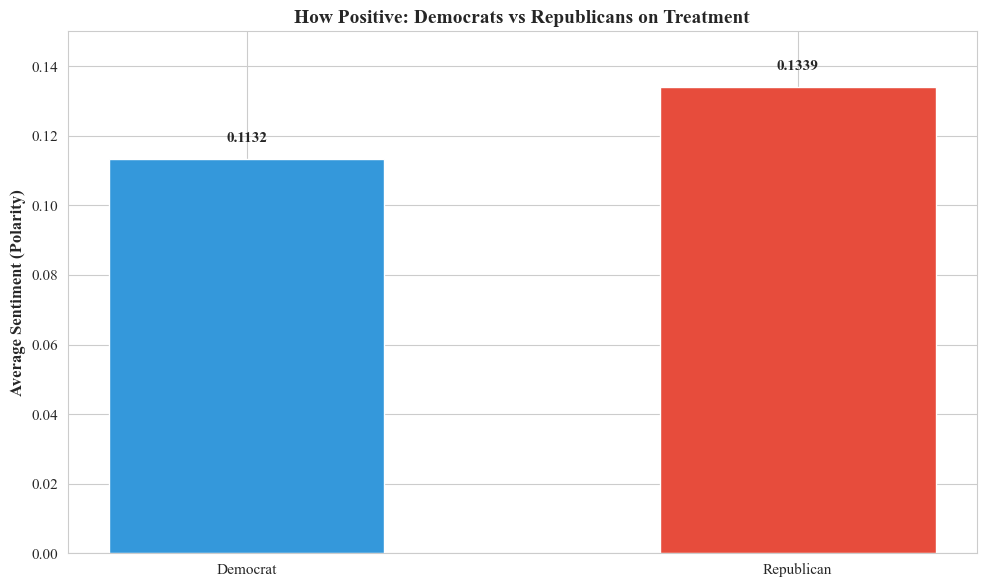

✓ Saved: mh_02_top_treatment_phrases.png


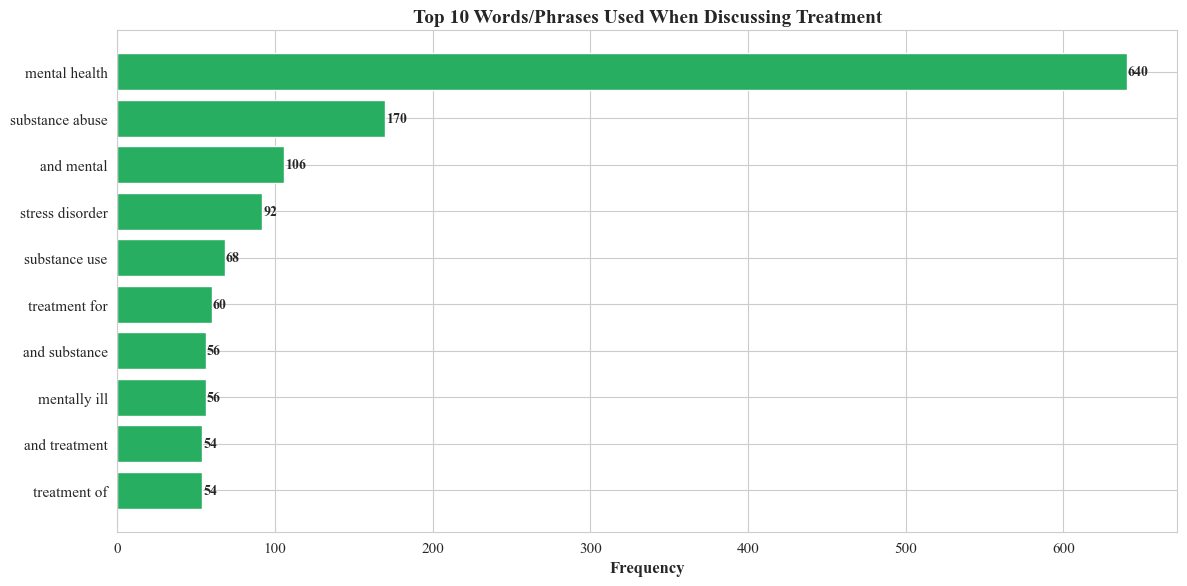

✓ Saved: mh_03_sentiment_distribution_party.png


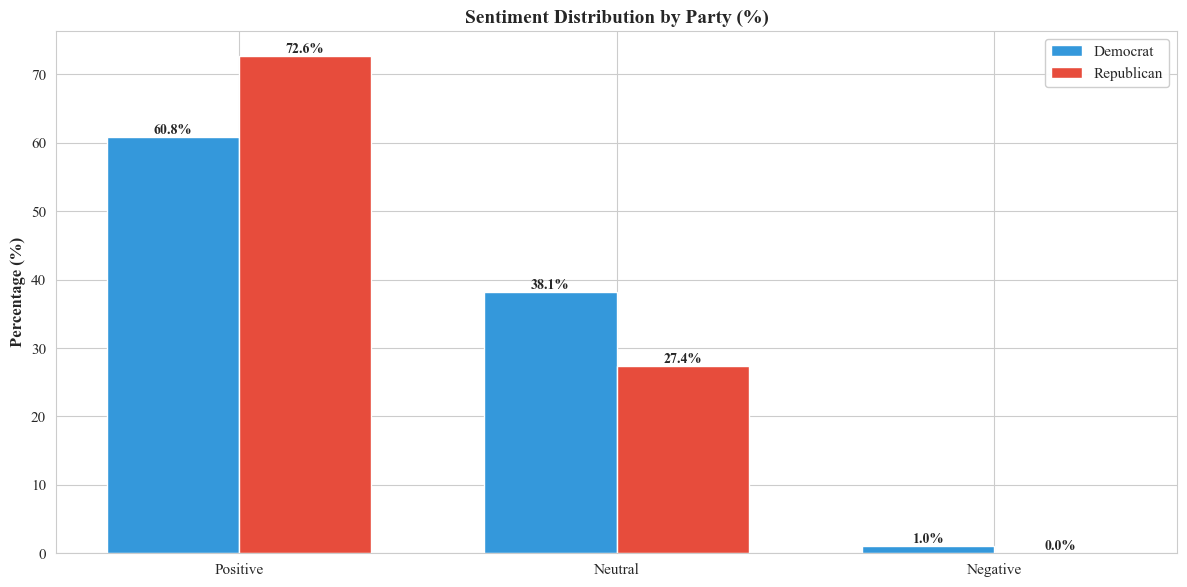

✓ Saved: mh_04_overall_sentiment_distribution.png


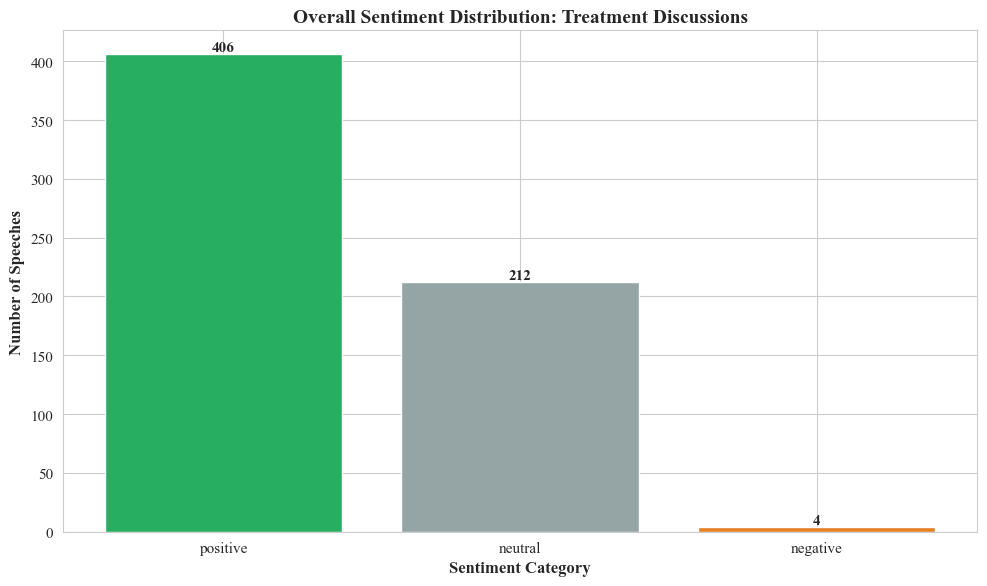

✓ Saved: mh_05_democrat_phrases.png


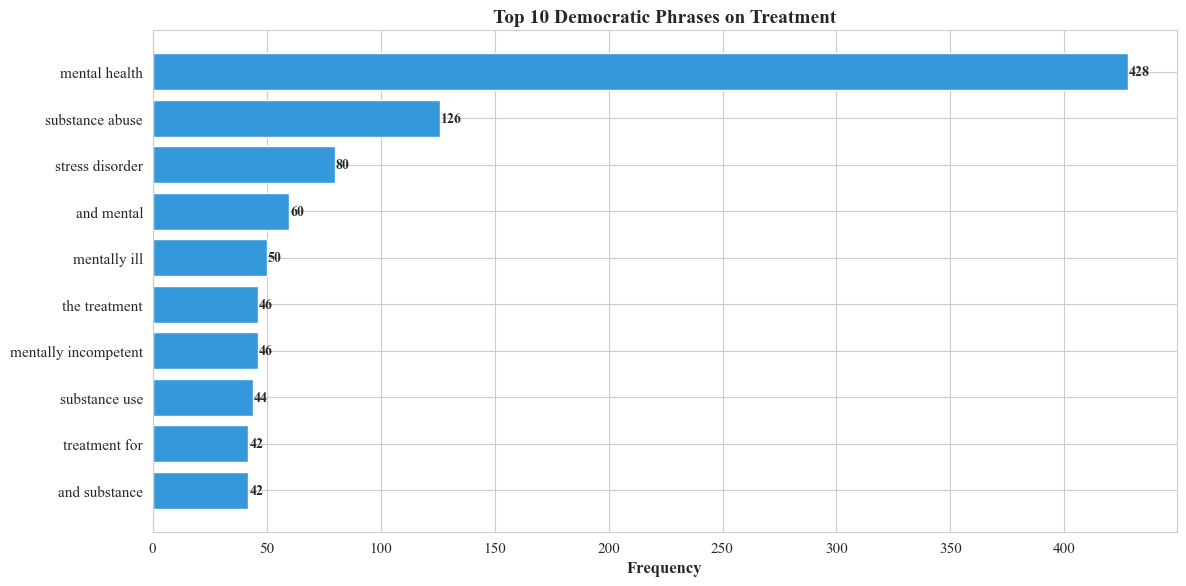

✓ Saved: mh_06_republican_phrases.png


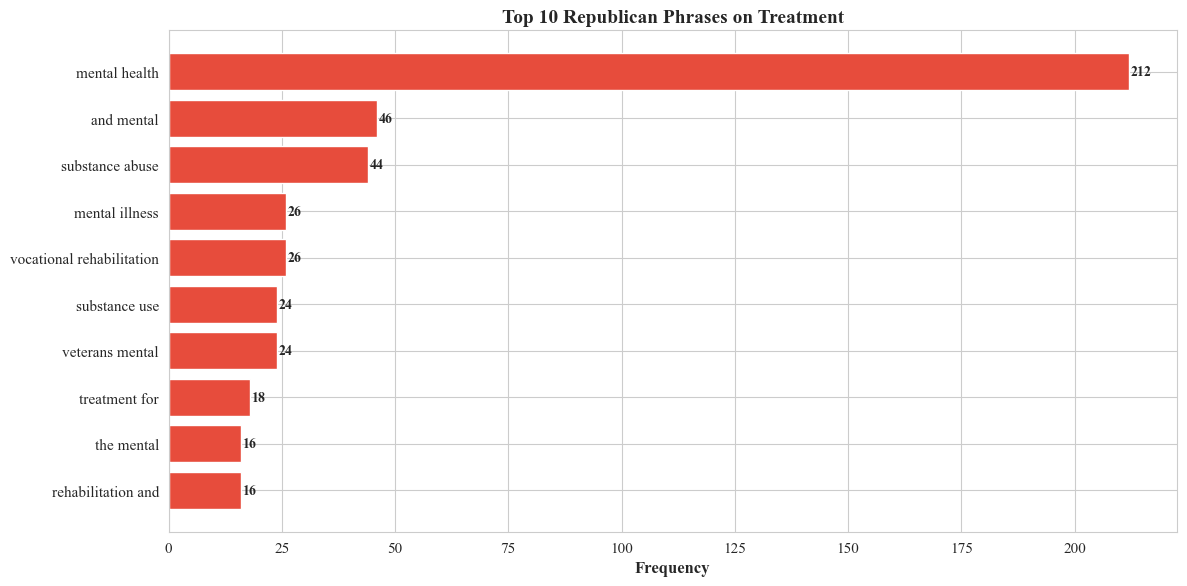


SUMMARY STATISTICS

TREATMENT DISCUSSION OVERVIEW:
  • Total speeches mentioning treatment: 622
  • Coverage of Topic 8 (Mental Health): 43.9%

OVERALL SENTIMENT:
  • Average polarity: 0.1210
  • Positive: 406 (65.3%)
  • Neutral: 212 (34.1%)
  • Negative: 4 (0.6%)

DEMOCRAT SPEECHES:
  • Count: 388
  • Average sentiment: 0.1132
  • Positive: 236 (60.8%)
  • Neutral: 148 (38.1%)
  • Negative: 4 (1.0%)

REPUBLICAN SPEECHES:
  • Count: 234
  • Average sentiment: 0.1339
  • Positive: 170 (72.6%)
  • Neutral: 64 (27.4%)
  • Negative: 0 (0.0%)

PARTY DIFFERENCE:
  • Difference: -0.0207
  • Status: Republicans more positive about treatment

✓ Saved: MENTAL_HEALTH_TREATMENT_ANALYSIS.csv


In [20]:
from collections import Counter
import re

# Set font to Times New Roman globally
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# Load data
homelessness = pd.read_csv('HOMELESSNESS_WITH_TOPICS_CLEANED.csv')

# Remove Independents
homelessness = homelessness[homelessness['Party'].isin(['Democrat', 'Republican'])].copy()

print("="*80)
print("HOW CONGRESS DISCUSSES MENTAL HEALTH TREATMENT")
print("="*80)

# STEP 1: FILTER FOR TREATMENT DISCUSSIONS

treatment_keywords = [
    'treatment', 'therapy', 'counseling', 'medication', 'substance', 'addiction',
    'behavioral', 'intervention', 'psychiatric', 'mental', 'depression', 'anxiety',
    'recovery', 'rehabilitation', 'clinical', 'diagnosis', 'disorder'
]

def has_treatment_keywords(text):
    if pd.isna(text):
        return False
    return any(keyword in str(text).lower() for keyword in treatment_keywords)

homelessness['mentions_treatment'] = homelessness['speech_text'].apply(has_treatment_keywords)

# Filter for Topic 8 (Mental Health) + Treatment keywords
mental_health = homelessness[
    (homelessness['dominant_topic'] == 8) &
    (homelessness['mentions_treatment'] == True)
].copy()

print(f"\nTotal Topic 8 speeches: {(homelessness['dominant_topic'] == 8).sum()}")
print(f"Those mentioning treatment: {len(mental_health)}")
print(f"Coverage: {len(mental_health)/(homelessness['dominant_topic'] == 8).sum()*100:.1f}%")

# STEP 2: SENTIMENT OF TREATMENT DISCUSSIONS

print("\n" + "="*80)
print("SENTIMENT: HOW POSITIVE/NEGATIVE IS TREATMENT DISCUSSION?")
print("="*80)

def get_sentiment(text):
    if pd.isna(text):
        return None, None
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        label = 'positive'
    elif polarity < -0.1:
        label = 'negative'
    else:
        label = 'neutral'
    return polarity, label

mental_health[['polarity', 'sentiment']] = mental_health['speech_text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(f"\nAverage sentiment: {mental_health['polarity'].mean():.4f}")
print(f"\nSentiment breakdown:")
for sentiment in ['positive', 'neutral', 'negative']:
    count = (mental_health['sentiment'] == sentiment).sum()
    pct = count / len(mental_health) * 100
    print(f"  {sentiment:10s}: {count:4d} ({pct:5.1f}%)")

# STEP 3: PARTY COMPARISON

print("\n" + "="*80)
print("PARTY COMPARISON: HOW DO DEMOCRATS & REPUBLICANS DIFFER?")
print("="*80)

dem_mh = mental_health[mental_health['Party'] == 'Democrat']
rep_mh = mental_health[mental_health['Party'] == 'Republican']

dem_avg = dem_mh['polarity'].mean()
rep_avg = rep_mh['polarity'].mean()

print(f"\nDemocrats:")
print(f"  Speeches: {len(dem_mh)}")
print(f"  Avg sentiment: {dem_avg:.4f}")
print(f"  Positive: {(dem_mh['sentiment'] == 'positive').sum()} ({(dem_mh['sentiment'] == 'positive').sum()/len(dem_mh)*100:.1f}%)")
print(f"  Neutral: {(dem_mh['sentiment'] == 'neutral').sum()} ({(dem_mh['sentiment'] == 'neutral').sum()/len(dem_mh)*100:.1f}%)")
print(f"  Negative: {(dem_mh['sentiment'] == 'negative').sum()} ({(dem_mh['sentiment'] == 'negative').sum()/len(dem_mh)*100:.1f}%)")

print(f"\nRepublicans:")
print(f"  Speeches: {len(rep_mh)}")
print(f"  Avg sentiment: {rep_avg:.4f}")
print(f"  Positive: {(rep_mh['sentiment'] == 'positive').sum()} ({(rep_mh['sentiment'] == 'positive').sum()/len(rep_mh)*100:.1f}%)")
print(f"  Neutral: {(rep_mh['sentiment'] == 'neutral').sum()} ({(rep_mh['sentiment'] == 'neutral').sum()/len(rep_mh)*100:.1f}%)")
print(f"  Negative: {(rep_mh['sentiment'] == 'negative').sum()} ({(rep_mh['sentiment'] == 'negative').sum()/len(rep_mh)*100:.1f}%)")

print(f"\nDifference: {dem_avg - rep_avg:+.4f}")
if abs(dem_avg - rep_avg) < 0.01:
    print("→ No significant party difference")
elif dem_avg > rep_avg:
    print("→ Democrats more positive about treatment")
else:
    print("→ Republicans more positive about treatment")

# STEP 4: WHAT LANGUAGE DO THEY USE?

print("\n" + "="*80)
print("KEY PHRASES USED WHEN DISCUSSING TREATMENT")
print("="*80)

# Extract phrases around treatment keywords
phrases = []

for text in mental_health['speech_text']:
    if pd.isna(text):
        continue

    text_lower = str(text).lower()

    # Find treatment keywords and their context
    for keyword in treatment_keywords:
        if keyword in text_lower:
            # Find words around the keyword
            words = re.findall(r'\b[a-z]+\b', text_lower)
            for i, word in enumerate(words):
                if keyword in word:
                    # Get 2-word phrases around keyword
                    if i > 0 and i < len(words) - 1:
                        phrases.append(f"{words[i-1]} {word}")
                        phrases.append(f"{word} {words[i+1]}")

phrase_freq = Counter(phrases)

print(f"\nTop 20 phrases mentioning treatment:")
for i, (phrase, count) in enumerate(phrase_freq.most_common(20), 1):
    print(f"{i:2d}. {phrase:40s} : {count:3d}")

# STEP 5: DEMOCRAT vs REPUBLICAN PHRASES

print("\n" + "="*80)
print("LANGUAGE DIFFERENCES: DEMOCRATS vs REPUBLICANS")
print("="*80)

dem_phrases = []
for text in dem_mh['speech_text']:
    if pd.isna(text):
        continue
    text_lower = str(text).lower()
    for keyword in treatment_keywords:
        if keyword in text_lower:
            words = re.findall(r'\b[a-z]+\b', text_lower)
            for i, word in enumerate(words):
                if keyword in word:
                    if i > 0 and i < len(words) - 1:
                        dem_phrases.append(f"{words[i-1]} {word}")
                        dem_phrases.append(f"{word} {words[i+1]}")

rep_phrases = []
for text in rep_mh['speech_text']:
    if pd.isna(text):
        continue
    text_lower = str(text).lower()
    for keyword in treatment_keywords:
        if keyword in text_lower:
            words = re.findall(r'\b[a-z]+\b', text_lower)
            for i, word in enumerate(words):
                if keyword in word:
                    if i > 0 and i < len(words) - 1:
                        rep_phrases.append(f"{words[i-1]} {word}")
                        rep_phrases.append(f"{word} {words[i+1]}")

dem_freq = Counter(dem_phrases)
rep_freq = Counter(rep_phrases)

print(f"\nTop Democrat phrases:")
for phrase, count in dem_freq.most_common(10):
    print(f"  • {phrase:35s} : {count:3d}")

print(f"\nTop Republican phrases:")
for phrase, count in rep_freq.most_common(10):
    print(f"  • {phrase:35s} : {count:3d}")

# STEP 6: EXAMPLE QUOTES

print("\n" + "="*80)
print("EXAMPLE QUOTES ABOUT TREATMENT")
print("="*80)

# Positive example
pos = mental_health[mental_health['sentiment'] == 'positive']
if len(pos) > 0:
    example = pos.iloc[0]
    sentences = example['speech_text'].split('.')
    for sentence in sentences:
        if any(keyword in sentence.lower() for keyword in treatment_keywords):
            print(f"\nPOSITIVE ({example['Party']}):")
            print(f"\"{sentence.strip()}\"")
            print(f"Sentiment: {example['polarity']:.3f}")
            break

# Negative example
neg = mental_health[mental_health['sentiment'] == 'negative']
if len(neg) > 0:
    example = neg.iloc[0]
    sentences = example['speech_text'].split('.')
    for sentence in sentences:
        if any(keyword in sentence.lower() for keyword in treatment_keywords):
            print(f"\nNEGATIVE ({example['Party']}):")
            print(f"\"{sentence.strip()}\"")
            print(f"Sentiment: {example['polarity']:.3f}")
            break


# GRAPH 1: PARTY SENTIMENT COMPARISON


fig, ax = plt.subplots(figsize=(10, 6))

parties = ['Democrat', 'Republican']
values = [dem_avg, rep_avg]
colors = ['#3498db', '#e74c3c']

bars = ax.bar(parties, values, color=colors, width=0.5)

ax.set_ylabel('Average Sentiment (Polarity)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('How Positive: Democrats vs Republicans on Treatment', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylim(0, 0.15)

for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('mh_01_party_sentiment_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mh_01_party_sentiment_comparison.png")
plt.show()


# GRAPH 2: TOP TREATMENT PHRASES


fig, ax = plt.subplots(figsize=(12, 6))

top_10_phrases = dict(phrase_freq.most_common(10))
phrases_list = list(top_10_phrases.keys())
frequencies = list(top_10_phrases.values())

bars = ax.barh(phrases_list, frequencies, color='#27ae60')
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Top 10 Words/Phrases Used When Discussing Treatment', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.invert_yaxis()

for i, (bar, freq) in enumerate(zip(bars, frequencies)):
    ax.text(freq + 0.5, i, f'{int(freq)}', va='center', fontweight='bold', fontsize=10, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('mh_02_top_treatment_phrases.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mh_02_top_treatment_phrases.png")
plt.show()


# GRAPH 3: SENTIMENT DISTRIBUTION BY PARTY (%)


fig, ax = plt.subplots(figsize=(12, 6))

sentiment_categories = ['Positive', 'Neutral', 'Negative']
dem_percentages = [
    (dem_mh['sentiment'] == 'positive').sum() / len(dem_mh) * 100,
    (dem_mh['sentiment'] == 'neutral').sum() / len(dem_mh) * 100,
    (dem_mh['sentiment'] == 'negative').sum() / len(dem_mh) * 100
]
rep_percentages = [
    (rep_mh['sentiment'] == 'positive').sum() / len(rep_mh) * 100,
    (rep_mh['sentiment'] == 'neutral').sum() / len(rep_mh) * 100,
    (rep_mh['sentiment'] == 'negative').sum() / len(rep_mh) * 100
]

x = range(len(sentiment_categories))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], dem_percentages, width, label='Democrat', color='#3498db')
bars2 = ax.bar([i + width/2 for i in x], rep_percentages, width, label='Republican', color='#e74c3c')

ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Sentiment Distribution by Party (%)', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_xticks(x)
ax.set_xticklabels(sentiment_categories, fontsize=11, fontfamily='Times New Roman')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold', fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('mh_03_sentiment_distribution_party.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mh_03_sentiment_distribution_party.png")
plt.show()


# GRAPH 4: OVERALL SENTIMENT DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

sentiment_counts = mental_health['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors_ordered = ['#27ae60', '#95a5a6', '#e67e22']

bars = ax.bar(sentiment_counts.index, sentiment_counts.values, color=colors_ordered)

ax.set_title('Overall Sentiment Distribution: Treatment Discussions', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Number of Speeches', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_xlabel('Sentiment Category', fontsize=12, fontweight='bold', fontfamily='Times New Roman')

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('mh_04_overall_sentiment_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mh_04_overall_sentiment_distribution.png")
plt.show()


# GRAPH 5: TOP DEMOCRAT PHRASES


fig, ax = plt.subplots(figsize=(12, 6))

top_dem_phrases = dict(dem_freq.most_common(10))
dem_phrases_list = list(top_dem_phrases.keys())
dem_frequencies = list(top_dem_phrases.values())

bars = ax.barh(dem_phrases_list, dem_frequencies, color='#3498db')
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Top 10 Democratic Phrases on Treatment', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.invert_yaxis()

for i, (bar, freq) in enumerate(zip(bars, dem_frequencies)):
    ax.text(freq + 0.3, i, f'{int(freq)}', va='center', fontweight='bold', fontsize=10, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('mh_05_democrat_phrases.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mh_05_democrat_phrases.png")
plt.show()


# GRAPH 6: TOP REPUBLICAN PHRASES


fig, ax = plt.subplots(figsize=(12, 6))

top_rep_phrases = dict(rep_freq.most_common(10))
rep_phrases_list = list(top_rep_phrases.keys())
rep_frequencies = list(top_rep_phrases.values())

bars = ax.barh(rep_phrases_list, rep_frequencies, color='#e74c3c')
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Top 10 Republican Phrases on Treatment', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.invert_yaxis()

for i, (bar, freq) in enumerate(zip(bars, rep_frequencies)):
    ax.text(freq + 0.3, i, f'{int(freq)}', va='center', fontweight='bold', fontsize=10, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('mh_06_republican_phrases.png', dpi=300, bbox_inches='tight')
print("✓ Saved: mh_06_republican_phrases.png")
plt.show()


# SUMMARY STATISTICS


print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTREATMENT DISCUSSION OVERVIEW:")
print(f"  • Total speeches mentioning treatment: {len(mental_health):,}")
print(f"  • Coverage of Topic 8 (Mental Health): {len(mental_health)/(homelessness['dominant_topic'] == 8).sum()*100:.1f}%")

print(f"\nOVERALL SENTIMENT:")
print(f"  • Average polarity: {mental_health['polarity'].mean():.4f}")
print(f"  • Positive: {(mental_health['sentiment'] == 'positive').sum():,} ({(mental_health['sentiment'] == 'positive').sum()/len(mental_health)*100:.1f}%)")
print(f"  • Neutral: {(mental_health['sentiment'] == 'neutral').sum():,} ({(mental_health['sentiment'] == 'neutral').sum()/len(mental_health)*100:.1f}%)")
print(f"  • Negative: {(mental_health['sentiment'] == 'negative').sum():,} ({(mental_health['sentiment'] == 'negative').sum()/len(mental_health)*100:.1f}%)")

print(f"\nDEMOCRAT SPEECHES:")
print(f"  • Count: {len(dem_mh)}")
print(f"  • Average sentiment: {dem_avg:.4f}")
print(f"  • Positive: {(dem_mh['sentiment'] == 'positive').sum()} ({(dem_mh['sentiment'] == 'positive').sum()/len(dem_mh)*100:.1f}%)")
print(f"  • Neutral: {(dem_mh['sentiment'] == 'neutral').sum()} ({(dem_mh['sentiment'] == 'neutral').sum()/len(dem_mh)*100:.1f}%)")
print(f"  • Negative: {(dem_mh['sentiment'] == 'negative').sum()} ({(dem_mh['sentiment'] == 'negative').sum()/len(dem_mh)*100:.1f}%)")

print(f"\nREPUBLICAN SPEECHES:")
print(f"  • Count: {len(rep_mh)}")
print(f"  • Average sentiment: {rep_avg:.4f}")
print(f"  • Positive: {(rep_mh['sentiment'] == 'positive').sum()} ({(rep_mh['sentiment'] == 'positive').sum()/len(rep_mh)*100:.1f}%)")
print(f"  • Neutral: {(rep_mh['sentiment'] == 'neutral').sum()} ({(rep_mh['sentiment'] == 'neutral').sum()/len(rep_mh)*100:.1f}%)")
print(f"  • Negative: {(rep_mh['sentiment'] == 'negative').sum()} ({(rep_mh['sentiment'] == 'negative').sum()/len(rep_mh)*100:.1f}%)")

print(f"\nPARTY DIFFERENCE:")
print(f"  • Difference: {dem_avg - rep_avg:+.4f}")
if abs(dem_avg - rep_avg) < 0.01:
    print(f"  • Status: No significant difference")
elif dem_avg > rep_avg:
    print(f"  • Status: Democrats more positive about treatment")
else:
    print(f"  • Status: Republicans more positive about treatment")

print("\n" + "="*80)

# Save
mental_health.to_csv('MENTAL_HEALTH_TREATMENT_ANALYSIS.csv', index=False)
print("✓ Saved: MENTAL_HEALTH_TREATMENT_ANALYSIS.csv")

PUNITIVE LANGUAGE IN MENTAL HEALTH & HOMELESSNESS DISCOURSE

Topic 8 (Mental Health) Speeches: 1418
With PUNITIVE language: 194
Coverage: 13.7%
SENTIMENT OF PUNITIVE LANGUAGE

With punitive language: 0.1024
  Positive: 112 (57.7%)
  Neutral: 80 (41.2%)
  Negative: 2 (1.0%)

Without punitive language: 0.1296
Difference: -0.0272
PARTY COMPARISON: WHO USES PUNITIVE LANGUAGE?

Democrats:
  Total: 804
  With punitive language: 100 (12.4%)

Republicans:
  Total: 614
  With punitive language: 94 (15.3%)

Difference: +2.9%
→ Republicans use more punitive language
MOST COMMON PUNITIVE PHRASES

Top 15 punitive phrases:
 1. law enforcement                     :  44
 2. presiding officer                   :  22
 3. prisoners of                        :  20
 4. officers association                :  18
 5. officer mr                          :  18
 6. preventing crimes                   :  16
 7. crimes against                      :  16
 8. service officers                    :  14
 9. criminal ju

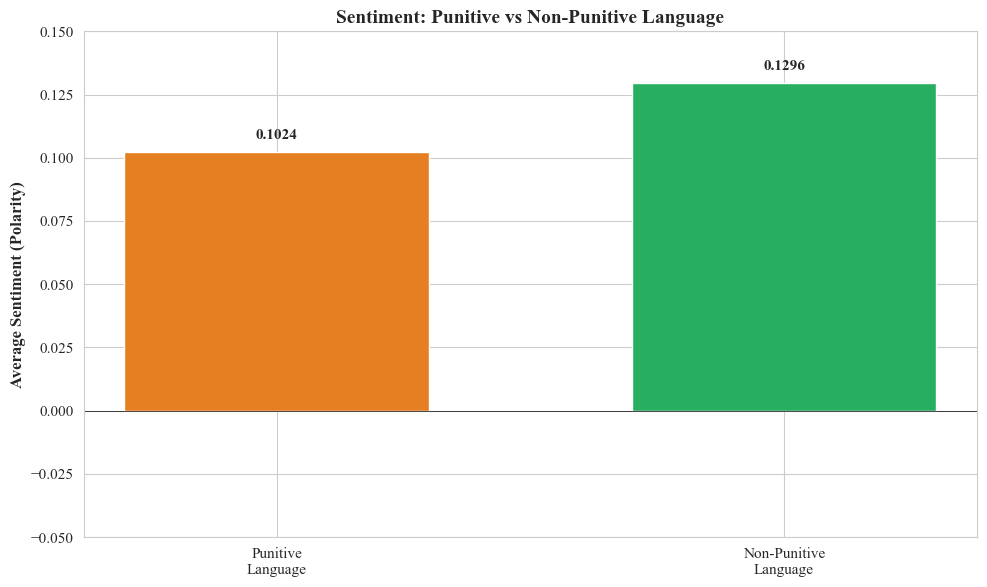

✓ Saved: pun_02_party_usage.png


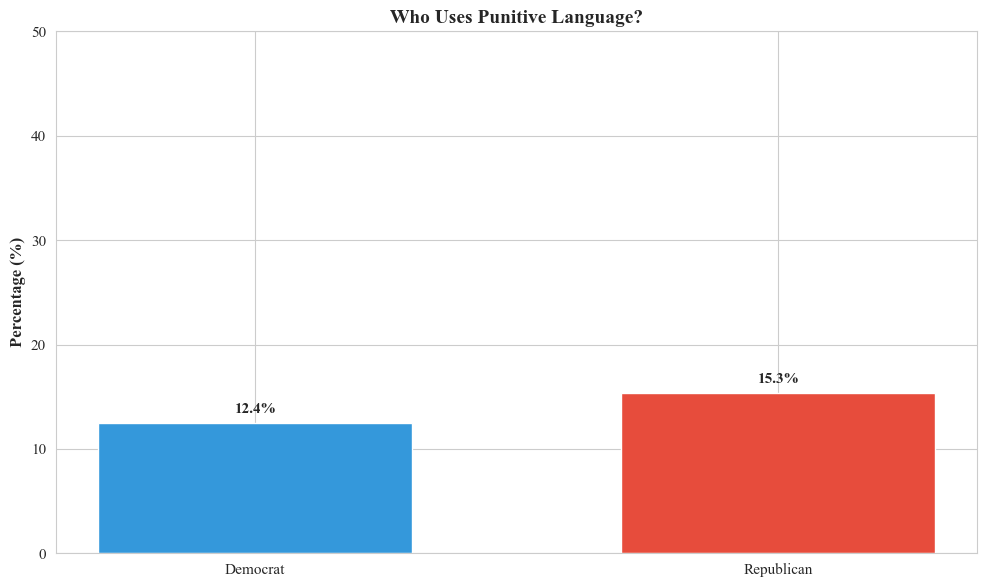

✓ Saved: pun_03_punitive_phrases.png


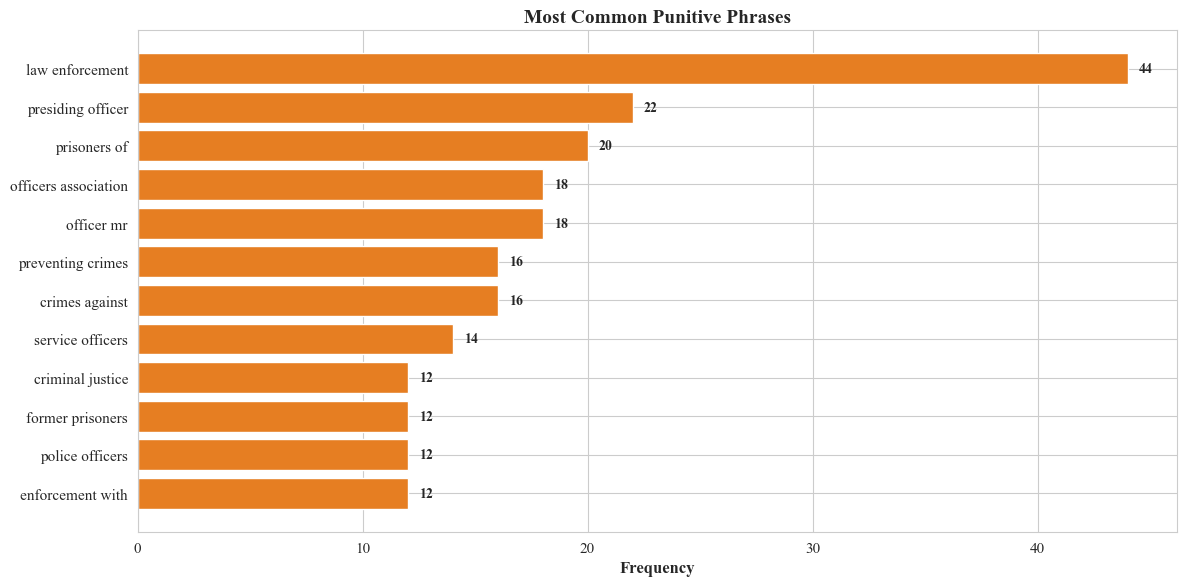

✓ Saved: pun_04_sentiment_distribution.png


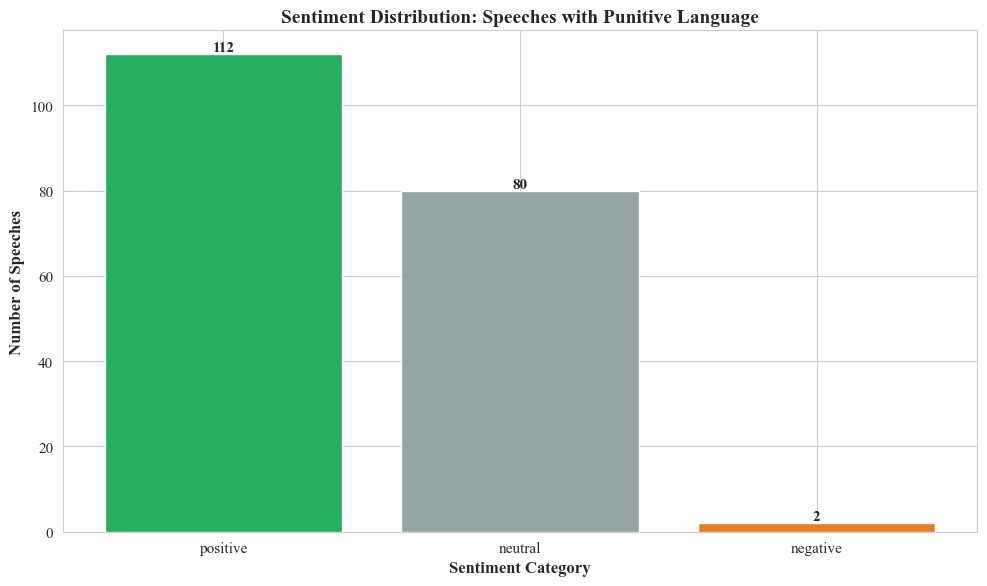

✓ Saved: pun_05_punitive_coverage.png


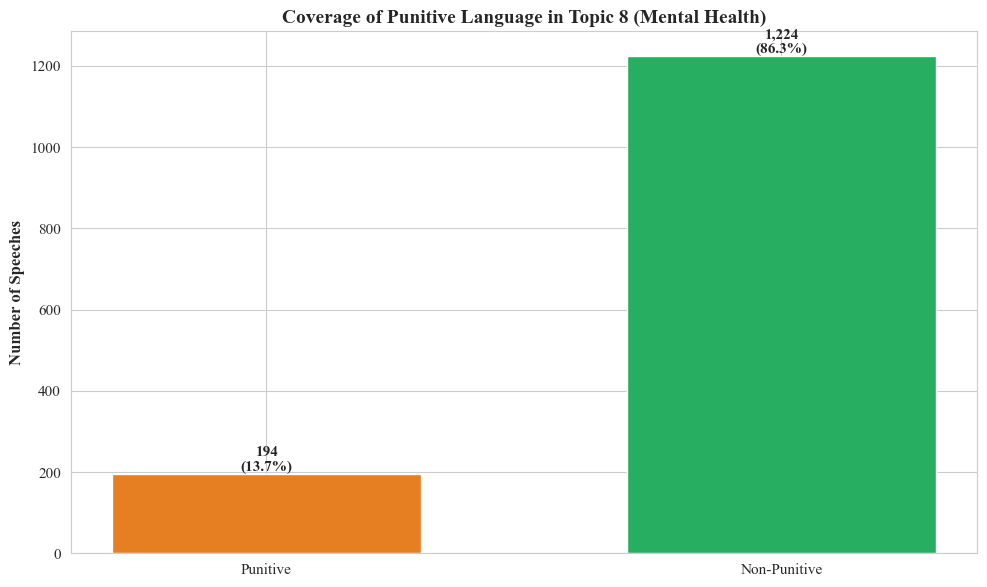

SUMMARY STATISTICS

OVERALL PUNITIVE LANGUAGE USAGE:
  • Speeches with punitive language: 194 of 1,418
  • Coverage: 13.7%

SENTIMENT OF PUNITIVE LANGUAGE:
  • Average polarity: 0.1024
  • Positive: 112 (57.7%)
  • Neutral: 80 (41.2%)
  • Negative: 2 (1.0%)

SENTIMENT OF NON-PUNITIVE LANGUAGE:
  • Average polarity: 0.1296

PARTY COMPARISON:
  • Democrats: 100 of 804 (12.4%)
  • Republicans: 94 of 614 (15.3%)
  • Difference: 2.9%
  • Status: Republicans use more punitive language

✓ Saved: MENTAL_HEALTH_PUNITIVE_LANGUAGE.csv


In [21]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Set font to Times New Roman globally
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# Load data
homelessness = pd.read_csv('HOMELESSNESS_WITH_TOPICS_CLEANED.csv')
homelessness = homelessness[homelessness['Party'].isin(['Democrat', 'Republican'])].copy()


print("PUNITIVE LANGUAGE IN MENTAL HEALTH & HOMELESSNESS DISCOURSE")


# STEP 1: IDENTIFY PUNITIVE KEYWORDS

punitive_keywords = [
    'crime', 'criminal', 'jail', 'prison', 'arrest', 'enforce',
    'enforcement', 'police', 'law enforcement', 'officer', 'incarcerate',
    'incarceration', 'punishment', 'punish', 'offender', 'defendant',
    'prosecution', 'prosecute', 'conviction', 'convict', 'sentence',
    'felony', 'misdemeanor', 'violation', 'penalt', 'illegal', 'unlawful'
]

def has_punitive_language(text):
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    return any(keyword in text_lower for keyword in punitive_keywords)

homelessness['has_punitive'] = homelessness['speech_text'].apply(has_punitive_language)

# STEP 2: FILTER FOR MENTAL HEALTH (TOPIC 8) WITH PUNITIVE LANGUAGE

mental_health_all = homelessness[homelessness['dominant_topic'] == 8].copy()
mental_health_punitive = homelessness[
    (homelessness['dominant_topic'] == 8) &
    (homelessness['has_punitive'] == True)
].copy()

print(f"\nTopic 8 (Mental Health) Speeches: {len(mental_health_all)}")
print(f"With PUNITIVE language: {len(mental_health_punitive)}")
print(f"Coverage: {len(mental_health_punitive)/len(mental_health_all)*100:.1f}%")

# STEP 3: SENTIMENT ANALYSIS


print("SENTIMENT OF PUNITIVE LANGUAGE")


def get_sentiment(text):
    if pd.isna(text):
        return None, None
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        label = 'positive'
    elif polarity < -0.1:
        label = 'negative'
    else:
        label = 'neutral'
    return polarity, label

mental_health_punitive[['polarity', 'sentiment']] = mental_health_punitive['speech_text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

mental_health_all[['polarity', 'sentiment']] = mental_health_all['speech_text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

punitive_avg = mental_health_punitive['polarity'].mean()
non_punitive_avg = mental_health_all[mental_health_all['has_punitive'] == False]['polarity'].mean()

print(f"\nWith punitive language: {punitive_avg:.4f}")
print(f"  Positive: {(mental_health_punitive['sentiment'] == 'positive').sum()} ({(mental_health_punitive['sentiment'] == 'positive').sum()/len(mental_health_punitive)*100:.1f}%)")
print(f"  Neutral: {(mental_health_punitive['sentiment'] == 'neutral').sum()} ({(mental_health_punitive['sentiment'] == 'neutral').sum()/len(mental_health_punitive)*100:.1f}%)")
print(f"  Negative: {(mental_health_punitive['sentiment'] == 'negative').sum()} ({(mental_health_punitive['sentiment'] == 'negative').sum()/len(mental_health_punitive)*100:.1f}%)")

print(f"\nWithout punitive language: {non_punitive_avg:.4f}")
print(f"Difference: {punitive_avg - non_punitive_avg:+.4f}")

# STEP 4: PARTY COMPARISON


print("PARTY COMPARISON: WHO USES PUNITIVE LANGUAGE?")


dem_all = mental_health_all[mental_health_all['Party'] == 'Democrat']
rep_all = mental_health_all[mental_health_all['Party'] == 'Republican']

dem_punitive = mental_health_punitive[mental_health_punitive['Party'] == 'Democrat']
rep_punitive = mental_health_punitive[mental_health_punitive['Party'] == 'Republican']

dem_pct = len(dem_punitive) / len(dem_all) * 100
rep_pct = len(rep_punitive) / len(rep_all) * 100

print(f"\nDemocrats:")
print(f"  Total: {len(dem_all)}")
print(f"  With punitive language: {len(dem_punitive)} ({dem_pct:.1f}%)")

print(f"\nRepublicans:")
print(f"  Total: {len(rep_all)}")
print(f"  With punitive language: {len(rep_punitive)} ({rep_pct:.1f}%)")

print(f"\nDifference: {rep_pct - dem_pct:+.1f}%")
if abs(rep_pct - dem_pct) < 2:
    print("→ BIPARTISAN: Both parties equally use punitive language")
else:
    print(f"→ {'Republicans' if rep_pct > dem_pct else 'Democrats'} use more punitive language")

# STEP 5: PUNITIVE PHRASES


print("MOST COMMON PUNITIVE PHRASES")


punitive_phrases = []

for text in mental_health_punitive['speech_text']:
    if pd.isna(text):
        continue

    text_lower = str(text).lower()

    for keyword in punitive_keywords:
        if keyword in text_lower:
            words = re.findall(r'\b[a-z]+\b', text_lower)
            for i, word in enumerate(words):
                if keyword in word or keyword == word:
                    if i > 0 and i < len(words) - 1:
                        punitive_phrases.append(f"{words[i-1]} {word}")
                        if i < len(words) - 2:
                            punitive_phrases.append(f"{word} {words[i+1]}")

phrase_freq = Counter(punitive_phrases)

print(f"\nTop 15 punitive phrases:")
for i, (phrase, count) in enumerate(phrase_freq.most_common(15), 1):
    print(f"{i:2d}. {phrase:35s} : {count:3d}")

# EXAMPLE QUOTES


print("EXAMPLE QUOTES WITH PUNITIVE LANGUAGE")


neg_punitive = mental_health_punitive[mental_health_punitive['sentiment'] == 'negative']
if len(neg_punitive) > 0:
    example = neg_punitive.iloc[0]
    print(f"\nNEGATIVE & PUNITIVE ({example['Party']}):")
    print(f"\"{example['speech_text'][:250]}...\"")
    print(f"Sentiment: {example['polarity']:.3f}")

# GRAPH 1: SENTIMENT COMPARISON

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Punitive\nLanguage', 'Non-Punitive\nLanguage'],
              [punitive_avg, non_punitive_avg], color=['#e67e22', '#27ae60'], width=0.6)

ax.set_ylabel('Average Sentiment (Polarity)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Sentiment: Punitive vs Non-Punitive Language', fontweight='bold', fontsize=14, fontfamily='Times New Roman')
ax.set_ylim(-0.05, 0.15)

for i, (bar, val) in enumerate(zip(bars, [punitive_avg, non_punitive_avg])):
    ax.text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('pun_01_sentiment_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pun_01_sentiment_comparison.png")
plt.show()

# GRAPH 2: PARTY USAGE

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Democrat', 'Republican'], [dem_pct, rep_pct], color=['#3498db', '#e74c3c'], width=0.6)

ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Who Uses Punitive Language?', fontweight='bold', fontsize=14, fontfamily='Times New Roman')
ax.set_ylim(0, 50)

for i, (bar, val) in enumerate(zip(bars, [dem_pct, rep_pct])):
    ax.text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('pun_02_party_usage.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pun_02_party_usage.png")
plt.show()

# GRAPH 3: TOP PUNITIVE PHRASES

fig, ax = plt.subplots(figsize=(12, 6))

top_phrases = dict(phrase_freq.most_common(12))
phrases_list = list(top_phrases.keys())
frequencies = list(top_phrases.values())

bars = ax.barh(phrases_list, frequencies, color='#e67e22')
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Most Common Punitive Phrases', fontweight='bold', fontsize=14, fontfamily='Times New Roman')
ax.invert_yaxis()

for i, (bar, freq) in enumerate(zip(bars, frequencies)):
    ax.text(freq + 0.5, i, f'{int(freq)}', va='center', fontweight='bold', fontsize=10, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('pun_03_punitive_phrases.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pun_03_punitive_phrases.png")
plt.show()

# GRAPH 4: SENTIMENT DISTRIBUTION (PUNITIVE)

fig, ax = plt.subplots(figsize=(10, 6))

sentiment_counts = mental_health_punitive['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors_ordered = ['#27ae60', '#95a5a6', '#e67e22']

bars = ax.bar(sentiment_counts.index, sentiment_counts.values, color=colors_ordered)

ax.set_title('Sentiment Distribution: Speeches with Punitive Language', fontsize=14, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Number of Speeches', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_xlabel('Sentiment Category', fontsize=12, fontweight='bold', fontfamily='Times New Roman')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('pun_04_sentiment_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pun_04_sentiment_distribution.png")
plt.show()

# GRAPH 5: PUNITIVE VS NON-PUNITIVE BREAKDOWN

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Punitive', 'Non-Punitive']
counts = [len(mental_health_punitive), len(mental_health_all[mental_health_all['has_punitive'] == False])]
colors = ['#e67e22', '#27ae60']

bars = ax.bar(categories, counts, color=colors, width=0.6)

ax.set_ylabel('Number of Speeches', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Coverage of Punitive Language in Topic 8 (Mental Health)', fontsize=14, fontweight='bold', fontfamily='Times New Roman')

for bar, count in zip(bars, counts):
    height = bar.get_height()
    pct = count / len(mental_health_all) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('pun_05_punitive_coverage.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pun_05_punitive_coverage.png")
plt.show()

# SUMMARY STATISTICS


print("SUMMARY STATISTICS")


print(f"\nOVERALL PUNITIVE LANGUAGE USAGE:")
print(f"  • Speeches with punitive language: {len(mental_health_punitive):,} of {len(mental_health_all):,}")
print(f"  • Coverage: {len(mental_health_punitive)/len(mental_health_all)*100:.1f}%")

print(f"\nSENTIMENT OF PUNITIVE LANGUAGE:")
print(f"  • Average polarity: {punitive_avg:.4f}")
print(f"  • Positive: {(mental_health_punitive['sentiment'] == 'positive').sum():,} ({(mental_health_punitive['sentiment'] == 'positive').sum()/len(mental_health_punitive)*100:.1f}%)")
print(f"  • Neutral: {(mental_health_punitive['sentiment'] == 'neutral').sum():,} ({(mental_health_punitive['sentiment'] == 'neutral').sum()/len(mental_health_punitive)*100:.1f}%)")
print(f"  • Negative: {(mental_health_punitive['sentiment'] == 'negative').sum():,} ({(mental_health_punitive['sentiment'] == 'negative').sum()/len(mental_health_punitive)*100:.1f}%)")

print(f"\nSENTIMENT OF NON-PUNITIVE LANGUAGE:")
print(f"  • Average polarity: {non_punitive_avg:.4f}")

print(f"\nPARTY COMPARISON:")
print(f"  • Democrats: {len(dem_punitive)} of {len(dem_all)} ({dem_pct:.1f}%)")
print(f"  • Republicans: {len(rep_punitive)} of {len(rep_all)} ({rep_pct:.1f}%)")
print(f"  • Difference: {abs(rep_pct - dem_pct):.1f}%")
if abs(rep_pct - dem_pct) < 2:
    print(f"  • Status: BIPARTISAN - Both parties use punitive language at similar rates")
else:
    print(f"  • Status: {'Republicans' if rep_pct > dem_pct else 'Democrats'} use more punitive language")



# SAVE DATA

mental_health_punitive.to_csv('MENTAL_HEALTH_PUNITIVE_LANGUAGE.csv', index=False)
print("\n✓ Saved: MENTAL_HEALTH_PUNITIVE_LANGUAGE.csv")

TEMPORAL SENTIMENT TRENDS (1995-2025)

Calculating sentiment for homelessness speeches...

Decade breakdown:
decade
1995-2004    4166
2005-2014    3512
2015-2025    2274
Name: count, dtype: int64
HOMELESSNESS SENTIMENT BY DECADE

           polarity                       sentiment
              mean  median     std count  <lambda>
decade                                            
1995-2004   0.1136  0.1058  0.1279  4166      2176
2005-2014   0.0998  0.0885  0.1260  3512      1572
2015-2025   0.0910  0.0783  0.1145  2274       944

1995-2004:
  Speeches: 4166
  Avg Polarity: 0.1136
  Positive: 2176 (52.2%)
  Neutral: 1848 (44.4%)
  Negative: 142 (3.4%)

2005-2014:
  Speeches: 3512
  Avg Polarity: 0.0998
  Positive: 1572 (44.8%)
  Neutral: 1836 (52.3%)
  Negative: 104 (3.0%)

2015-2025:
  Speeches: 2274
  Avg Polarity: 0.0910
  Positive: 944 (41.5%)
  Neutral: 1282 (56.4%)
  Negative: 48 (2.1%)
HOMELESSNESS SENTIMENT BY DECADE & PARTY

1995-2004:
  Democrat: 0.1154
  Republican: 0.1118


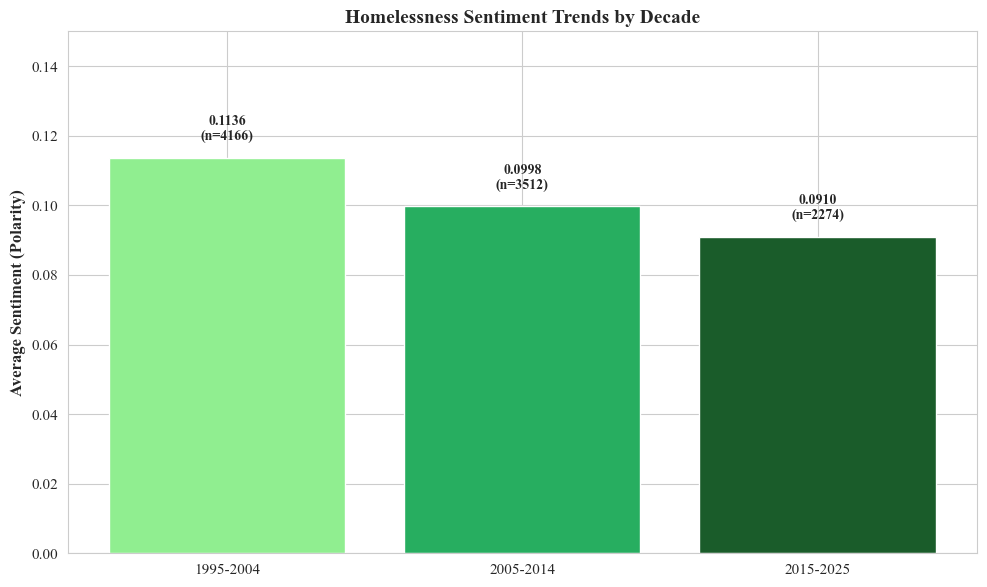

✓ Saved: temp_02_party_sentiment_by_decade.png


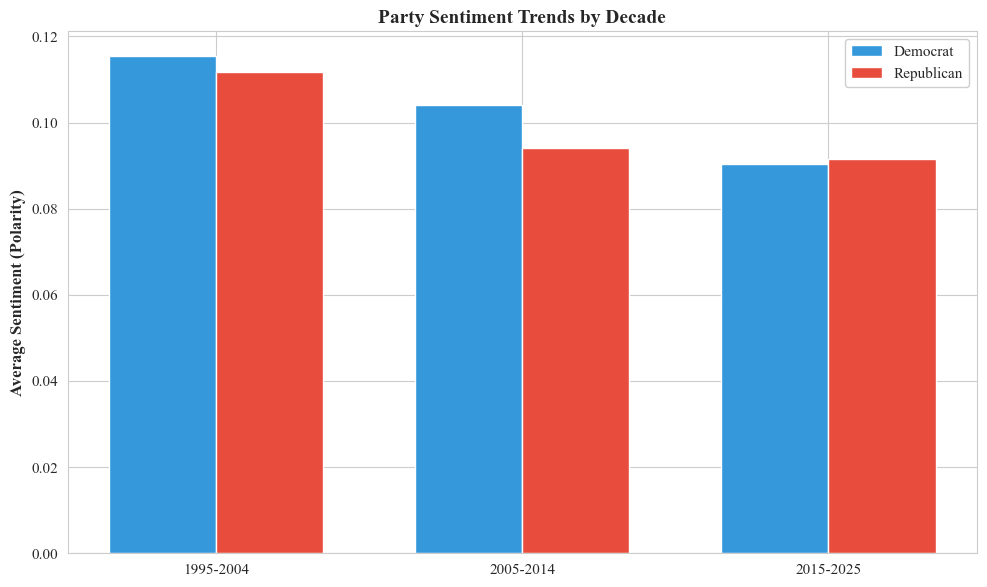

✓ Saved: temp_03_year_by_year_trend.png


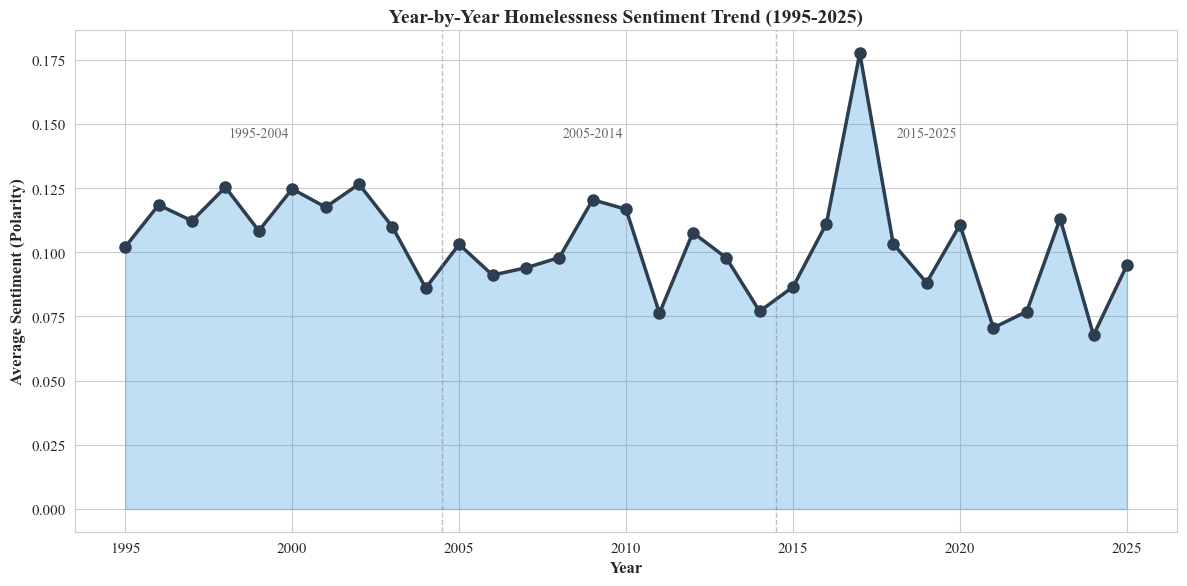

✓ Saved: temp_04_sentiment_distribution_by_decade.png


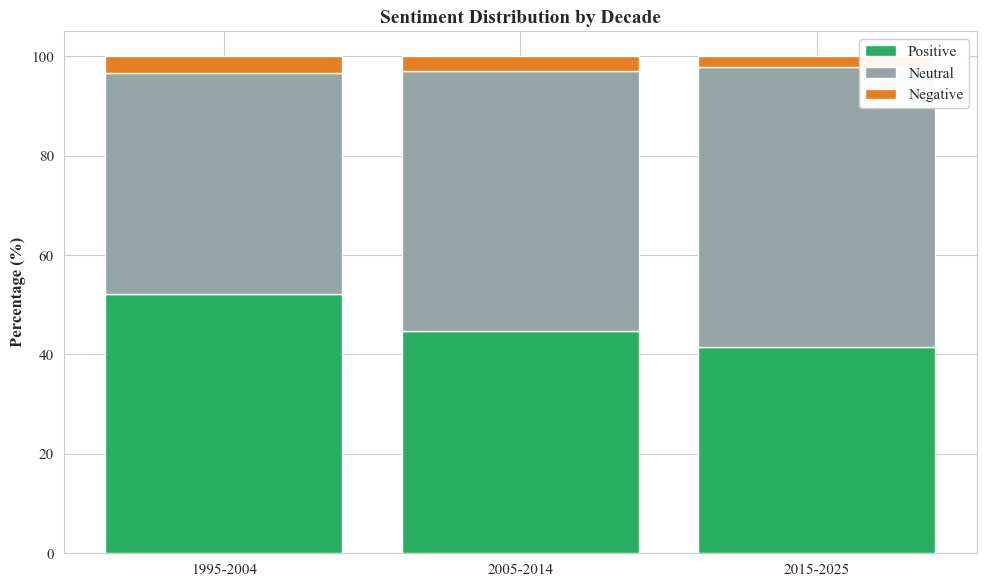

✓ Saved: temp_05_mental_health_sentiment_by_decade.png


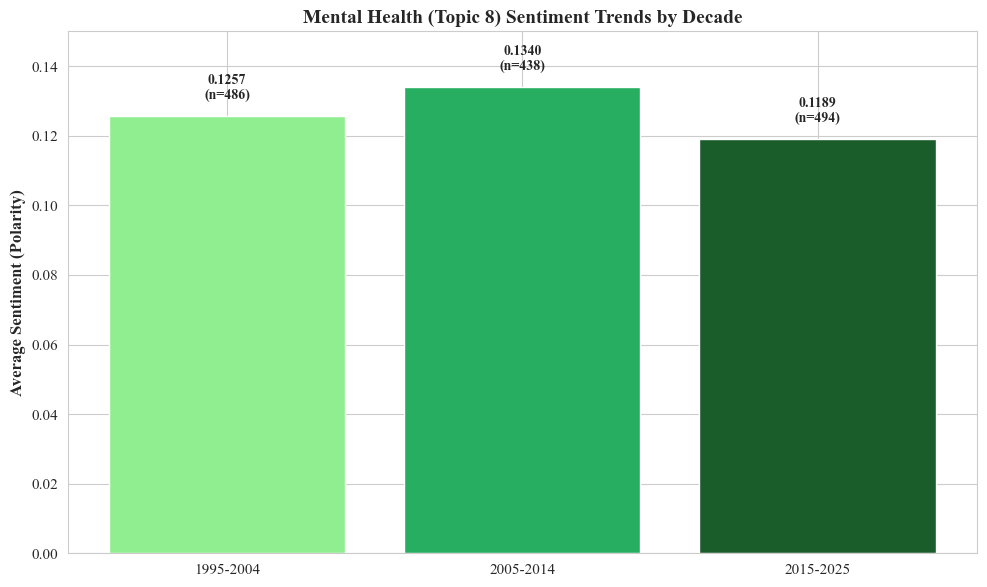


✓ Saved: HOMELESSNESS_WITH_DECADES.csv
SUMMARY

Trend Analysis:
  1995-2004: 0.1136
  2005-2014: 0.0998
  2015-2025: 0.0910

Change from 1995-2004 to 2015-2025: -0.0226


In [25]:
import numpy as np

# Set font to Times New Roman globally
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# Load data
homelessness = pd.read_csv('HOMELESSNESS_WITH_TOPICS_CLEANED.csv')
homelessness = homelessness[homelessness['Party'].isin(['Democrat', 'Republican'])].copy()

# Load all data for comparison
all_combined = pd.read_csv('COMBINED_DATA.csv')

print("TEMPORAL SENTIMENT TRENDS (1995-2025)")


# SENTIMENT FUNCTION


def get_sentiment(text):
    if pd.isna(text):
        return None, None
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        label = 'positive'
    elif polarity < -0.1:
        label = 'negative'
    else:
        label = 'neutral'
    return polarity, label

# Add sentiment if not already there
if 'polarity' not in homelessness.columns:
    print("\nCalculating sentiment for homelessness speeches...")
    homelessness[['polarity', 'sentiment']] = homelessness['speech_text'].apply(
        lambda x: pd.Series(get_sentiment(x))
    )


# CREATE 10-YEAR PERIODS


def assign_decade(year):
    if year < 2005:
        return '1995-2004'
    elif year < 2015:
        return '2005-2014'
    else:
        return '2015-2025'

homelessness['decade'] = homelessness['Year'].apply(assign_decade)

print(f"\nDecade breakdown:")
print(homelessness['decade'].value_counts().sort_index())


# ANALYZE BY DECADE: HOMELESSNESS



print("HOMELESSNESS SENTIMENT BY DECADE")

decade_sentiment = homelessness.groupby('decade').agg({
    'polarity': ['mean', 'median', 'std', 'count'],
    'sentiment': lambda x: (x == 'positive').sum()
}).round(4)

print("\n", decade_sentiment)

for decade in ['1995-2004', '2005-2014', '2015-2025']:
    decade_data = homelessness[homelessness['decade'] == decade]
    if len(decade_data) > 0:
        print(f"\n{decade}:")
        print(f"  Speeches: {len(decade_data)}")
        print(f"  Avg Polarity: {decade_data['polarity'].mean():.4f}")
        print(f"  Positive: {(decade_data['sentiment'] == 'positive').sum()} ({(decade_data['sentiment'] == 'positive').sum()/len(decade_data)*100:.1f}%)")
        print(f"  Neutral: {(decade_data['sentiment'] == 'neutral').sum()} ({(decade_data['sentiment'] == 'neutral').sum()/len(decade_data)*100:.1f}%)")
        print(f"  Negative: {(decade_data['sentiment'] == 'negative').sum()} ({(decade_data['sentiment'] == 'negative').sum()/len(decade_data)*100:.1f}%)")


# ANALYZE BY DECADE & PARTY



print("HOMELESSNESS SENTIMENT BY DECADE & PARTY")

for decade in ['1995-2004', '2005-2014', '2015-2025']:
    decade_data = homelessness[homelessness['decade'] == decade]

    dem = decade_data[decade_data['Party'] == 'Democrat']['polarity'].mean()
    rep = decade_data[decade_data['Party'] == 'Republican']['polarity'].mean()

    print(f"\n{decade}:")
    print(f"  Democrat: {dem:.4f}")
    print(f"  Republican: {rep:.4f}")
    print(f"  Difference: {dem - rep:+.4f}")


# YEAR-BY-YEAR TRENDS



print("YEAR-BY-YEAR SENTIMENT TRENDS")

yearly_sentiment = homelessness.groupby('Year')['polarity'].agg(['mean', 'count'])
print("\n", yearly_sentiment)


# GRAPH 1: HOMELESSNESS SENTIMENT BY DECADE


fig, ax = plt.subplots(figsize=(10, 6))

decades = ['1995-2004', '2005-2014', '2015-2025']
decade_avgs = [homelessness[homelessness['decade'] == d]['polarity'].mean() for d in decades]
decade_counts = [len(homelessness[homelessness['decade'] == d]) for d in decades]

bars = ax.bar(decades, decade_avgs, color=['#90EE90', '#27ae60', '#1a5c2a'])
ax.set_ylabel('Average Sentiment (Polarity)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Homelessness Sentiment Trends by Decade', fontweight='bold', fontsize=14, fontfamily='Times New Roman')
ax.set_ylim(0, 0.15)

for i, (bar, val, count) in enumerate(zip(bars, decade_avgs, decade_counts)):
    ax.text(i, val + 0.005, f'{val:.4f}\n(n={count})', ha='center', fontweight='bold', fontsize=10, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('temp_01_homelessness_sentiment_by_decade.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: temp_01_homelessness_sentiment_by_decade.png")
plt.show()


# GRAPH 2: PARTY COMPARISON BY DECADE


fig, ax = plt.subplots(figsize=(10, 6))

dem_decade = [homelessness[(homelessness['decade'] == d) & (homelessness['Party'] == 'Democrat')]['polarity'].mean() for d in decades]
rep_decade = [homelessness[(homelessness['decade'] == d) & (homelessness['Party'] == 'Republican')]['polarity'].mean() for d in decades]

x = np.arange(len(decades))
width = 0.35

ax.bar(x - width/2, dem_decade, width, label='Democrat', color='#3498db')
ax.bar(x + width/2, rep_decade, width, label='Republican', color='#e74c3c')

ax.set_ylabel('Average Sentiment (Polarity)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Party Sentiment Trends by Decade', fontweight='bold', fontsize=14, fontfamily='Times New Roman')
ax.set_xticks(x)
ax.set_xticklabels(decades, fontfamily='Times New Roman')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig('temp_02_party_sentiment_by_decade.png', dpi=300, bbox_inches='tight')
print("✓ Saved: temp_02_party_sentiment_by_decade.png")
plt.show()


# GRAPH 3: YEAR-BY-YEAR LINE GRAPH


fig, ax = plt.subplots(figsize=(12, 6))

years = yearly_sentiment.index
polarity = yearly_sentiment['mean']

ax.plot(years, polarity, marker='o', linewidth=2.5, markersize=8, color='#2c3e50')
ax.fill_between(years, polarity, alpha=0.3, color='#3498db')

ax.set_xlabel('Year', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel('Average Sentiment (Polarity)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Year-by-Year Homelessness Sentiment Trend (1995-2025)', fontweight='bold', fontsize=14, fontfamily='Times New Roman')

# Highlight decades
ax.axvline(x=2004.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=2014.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(1999, 0.145, '1995-2004', ha='center', fontsize=10, alpha=0.7, fontfamily='Times New Roman')
ax.text(2009, 0.145, '2005-2014', ha='center', fontsize=10, alpha=0.7, fontfamily='Times New Roman')
ax.text(2019, 0.145, '2015-2025', ha='center', fontsize=10, alpha=0.7, fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig('temp_03_year_by_year_trend.png', dpi=300, bbox_inches='tight')
print("✓ Saved: temp_03_year_by_year_trend.png")
plt.show()


# GRAPH 4: SENTIMENT DISTRIBUTION BY DECADE


fig, ax = plt.subplots(figsize=(10, 6))

sentiment_dist = []
for decade in decades:
    decade_data = homelessness[homelessness['decade'] == decade]
    pos_pct = (decade_data['sentiment'] == 'positive').sum() / len(decade_data) * 100
    neu_pct = (decade_data['sentiment'] == 'neutral').sum() / len(decade_data) * 100
    neg_pct = (decade_data['sentiment'] == 'negative').sum() / len(decade_data) * 100
    sentiment_dist.append([pos_pct, neu_pct, neg_pct])

sentiment_array = np.array(sentiment_dist)

ax.bar(decades, sentiment_array[:, 0], label='Positive', color='#27ae60')
ax.bar(decades, sentiment_array[:, 1], bottom=sentiment_array[:, 0], label='Neutral', color='#95a5a6')
ax.bar(decades, sentiment_array[:, 2], bottom=sentiment_array[:, 0] + sentiment_array[:, 1], label='Negative', color='#e67e22')

ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title('Sentiment Distribution by Decade', fontweight='bold', fontsize=14, fontfamily='Times New Roman')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig('temp_04_sentiment_distribution_by_decade.png', dpi=300, bbox_inches='tight')
print("✓ Saved: temp_04_sentiment_distribution_by_decade.png")
plt.show()


# GRAPH 5: TOPIC 8 (MENTAL HEALTH) OVER TIME


mental_health = homelessness[homelessness['dominant_topic'] == 8].copy()

if len(mental_health) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    mh_decades = ['1995-2004', '2005-2014', '2015-2025']
    mh_decade_avgs = [mental_health[mental_health['decade'] == d]['polarity'].mean() for d in mh_decades]
    mh_counts = [len(mental_health[mental_health['decade'] == d]) for d in mh_decades]

    bars = ax.bar(mh_decades, mh_decade_avgs, color=['#90EE90', '#27ae60', '#1a5c2a'])
    ax.set_ylabel('Average Sentiment (Polarity)', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
    ax.set_title('Mental Health (Topic 8) Sentiment Trends by Decade', fontweight='bold', fontsize=14, fontfamily='Times New Roman')
    ax.set_ylim(0, 0.15)

    for i, (bar, val, count) in enumerate(zip(bars, mh_decade_avgs, mh_counts)):
        ax.text(i, val + 0.005, f'{val:.4f}\n(n={count})', ha='center', fontweight='bold', fontsize=10, fontfamily='Times New Roman')

    plt.tight_layout()
    plt.savefig('temp_05_mental_health_sentiment_by_decade.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: temp_05_mental_health_sentiment_by_decade.png")
    plt.show()


# SAVE SUMMARY


homelessness.to_csv('HOMELESSNESS_WITH_DECADES.csv', index=False)
print("\n✓ Saved: HOMELESSNESS_WITH_DECADES.csv")


print("SUMMARY")
print("\nTrend Analysis:")
print(f"  1995-2004: {decade_avgs[0]:.4f}")
print(f"  2005-2014: {decade_avgs[1]:.4f}")
print(f"  2015-2025: {decade_avgs[2]:.4f}")
print(f"\nChange from 1995-2004 to 2015-2025: {decade_avgs[2] - decade_avgs[0]:+.4f}")